
# Acoustic Tomography




## 0.1 Import Libraries

In [1]:
# Generated with ChatGPT assistance and adapted for this project.

import time
import math
import itertools
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

SLOWNESS_MIN = 0.5
SLOWNESS_MAX = 10.0

N_MONTE_CARLO = 1000
NOISE_LEVELS = np.round(np.arange(0.00, 0.31, 0.05), 2)

NOISE_TYPES = [
    "Gaussian",
    "Uniform",
    "Laplace",
    "Multiplicative",
    "Impulsive"
]

OUTPUT_DIR = Path("final_clear_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("TensorFlow version:", tf.__version__)
print("Noise levels:", NOISE_LEVELS)
print("Noise types:", NOISE_TYPES)
print("Monte Carlo simulations per level:", N_MONTE_CARLO)


TensorFlow version: 2.20.0
Noise levels: [0.   0.05 0.1  0.15 0.2  0.25 0.3 ]
Noise types: ['Gaussian', 'Uniform', 'Laplace', 'Multiplicative', 'Impulsive']
Monte Carlo simulations per level: 1000


## 0.2 Reproducibility Details


In [2]:
import sys
import platform
import sklearn

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
print("TensorFlow:", tf.__version__)
print("Operating system:", platform.system(), platform.release())
print("Processor:", platform.processor())
print("Main random seed:", SEED)
print("Monte Carlo simulations:", N_MONTE_CARLO)

gpu_devices = tf.config.list_physical_devices("GPU")

if gpu_devices:
    print("GPU:", gpu_devices)
else:
    print("GPU: not available, CPU used")


Python: 3.13.15
NumPy: 2.1.3
Pandas: 2.2.3
Scikit-learn: 1.6.1
TensorFlow: 2.20.0
Operating system: Linux 6.6.122+
Processor: x86_64
Main random seed: 42
Monte Carlo simulations: 1000
GPU: not available, CPU used


## 0.2 Physical Relationship: Wave Speed and Slowness

In [3]:
def slowness_from_speed(c):
    return 1.0 / np.asarray(c, dtype=float)

def speed_from_slowness(s):
    return 1.0 / np.asarray(s, dtype=float)

# s = 1/c
# t = L/c = L*s

## 0.3 Geometry Functions and Sensitivity Matrix

In [4]:
# This code snippet was generated with assistance from ChatGPT.
# Calculates how much of a ray passes through one grid cell

def segment_rectangle_intersection_length(
    p0, p1, xmin, xmax, ymin, ymax, eps=1e-12
):
    x0, y0 = p0
    x1, y1 = p1
    dx = x1 - x0
    dy = y1 - y0

    t_enter, t_exit = 0.0, 1.0

# Check where the ray enters and leaves the rectangle

    for p, q in [
        (-dx, x0 - xmin),
        ( dx, xmax - x0),
        (-dy, y0 - ymin),
        ( dy, ymax - y0),
    ]:
        if abs(p) < eps:
            if q < 0:
                return 0.0
        else:
            ratio = q / p

            if p < 0:
                if ratio > t_exit:
                    return 0.0
                t_enter = max(t_enter, ratio)
            else:
                if ratio < t_enter:
                    return 0.0
                t_exit = min(t_exit, ratio)

    if t_exit <= t_enter:
        return 0.0

    return (t_exit - t_enter) * math.hypot(dx, dy)


def create_boundary_points(n):
    points = []
    extent = float(n)

    for i in range(n):
        centre = i + 0.5
        points.extend([
            ("L", i + 1, (0.0, centre)),
            ("R", i + 1, (extent, centre)),
            ("B", i + 1, (centre, 0.0)),
            ("T", i + 1, (centre, extent)),
        ])

    return points

# Creates the different ray paths between boundary points

def build_ray_geometry(n):
    points = create_boundary_points(n)
    rays = []
    seen = set()

    for a, b in itertools.combinations(points, 2):
        side_a, num_a, start = a
        side_b, num_b, end = b

        if side_a == side_b:
            continue

        key = tuple(sorted((start, end)))

        if key in seen:
            continue

        seen.add(key)

        dx = end[0] - start[0]
        dy = end[1] - start[1]

        if abs(dy) < 1e-12:
            ray_type = "Horizontal"
        elif abs(dx) < 1e-12:
            ray_type = "Vertical"
        else:
            ray_type = "Diagonal"

        rays.append({
            "name": f"{side_a}{num_a}-{side_b}{num_b}",
            "type": ray_type,
            "start": start,
            "end": end
        })

    return rays


def build_sensitivity_matrix(n, rays):
    rows = []

    for ray in rays:
        row = []

        for display_row in range(n):
            geometric_row = n - 1 - display_row

            for col in range(n):
                xmin, xmax = float(col), float(col + 1)
                ymin, ymax = float(geometric_row), float(geometric_row + 1)

                length = segment_rectangle_intersection_length(
                    ray["start"], ray["end"],
                    xmin, xmax, ymin, ymax
                )

                row.append(length)

        rows.append(row)

    return np.asarray(rows, dtype=float)


def build_2x2_square_matrix():

# 2x2 case has four travel time measurements and four unknown slowness values

    K = np.array([
        [1.0, 1.0, 0.0, 0.0],  # T1
        [0.0, 0.0, 1.0, 1.0],  # T2
        [1.0, 0.0, 1.0, 0.0],  # T3
        [1.0, 0.0, 0.0, 1.0],  # T4
    ], dtype=float)

    return K


def build_problem(n):
    if n == 2:
        K = build_2x2_square_matrix()
        rays = None
    else:
        rays = build_ray_geometry(n)
        K = build_sensitivity_matrix(n, rays)

# Check that there is enough independent information to solve the problem

    if np.linalg.matrix_rank(K) < n*n:
        raise ValueError(
            f"{n}x{n} matrix is not full column rank."
        )

    return K, rays


## 0.4 Forward Model, Analytical Reconstruction and Metrics

In [5]:
# This code snippet was generated with assistance from ChatGPT.
# Calculates the measurements from the slowness values

def forward_model(K, m):
    return K @ np.asarray(m, dtype=float)


def forward_model_batch(K, M):
    return np.asarray(M, dtype=float) @ K.T

# Reconstructs the slowness values from the measurements

def analytical_reconstruction(K, d):
    d = np.asarray(d, dtype=float)

# If K is square, solve the equations directly

    if K.shape[0] == K.shape[1]:
        return np.linalg.solve(K, d)

# Otherwise use least squares to find the best solution

    m_hat, _, _, _ = np.linalg.lstsq(K, d, rcond=None)
    return m_hat

def analytical_reconstruction_batch(K, D):
    D = np.asarray(D, dtype=float)

    if K.shape[0] == K.shape[1]:
        return np.linalg.solve(K, D.T).T

    K_plus = np.linalg.pinv(K)
    return D @ K_plus.T

# Calculates the errors and accuracy of the reconstruction

def reconstruction_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mse = float(np.mean((y_true - y_pred)**2))
    rmse = float(np.sqrt(mse))

    if y_true.ndim == 1:
        relative_error = (
            np.linalg.norm(y_true - y_pred)
            / max(np.linalg.norm(y_true), 1e-12)
        ) * 100.0
    else:
        sample_relative_errors = (
            np.linalg.norm(y_true - y_pred, axis=1)
            / np.maximum(np.linalg.norm(y_true, axis=1), 1e-12)
        )

        relative_error = float(
            np.mean(sample_relative_errors) * 100.0
        )

    accuracy = 100.0 - relative_error

    return {
        "MSE": mse,
        "RMSE": rmse,
        "Relative Error (%)": relative_error,
        "Accuracy (%)": accuracy
    }


## 0.5 All Five Noise Types

In [6]:
# Generated with ChatGPT assistance and adapted for this project.
def add_noise_batch(D, noise_type, level, rng):
    D = np.asarray(D, dtype=float)

    if level <= 0:
        return D.copy()

    row_scale = np.std(D, axis=1, keepdims=True)
    row_scale = np.maximum(row_scale, 1e-8)

    sigma = level * row_scale

    if noise_type == "Gaussian":
        return D + rng.normal(0.0, 1.0, D.shape) * sigma

    if noise_type == "Uniform":
        half_width = np.sqrt(3.0) * sigma
        return D + rng.uniform(
            -1.0, 1.0, D.shape
        ) * half_width

    if noise_type == "Laplace":
        return D + rng.laplace(
            0.0, 1.0, D.shape
        ) * (sigma / np.sqrt(2.0))

    if noise_type == "Multiplicative":
        return D * (
            1.0 + rng.normal(0.0, level, D.shape)
        )

    if noise_type == "Impulsive":
        noisy = D.copy()

        probability = min(
            0.50,
            max(0.02, float(level))
        )

        mask = rng.random(D.shape) < probability

        impulses = rng.normal(
            0.0, 1.0, D.shape
        ) * (5.0 * sigma)

        noisy[mask] += impulses[mask]

        return noisy

    raise ValueError(
        f"Unknown noise type: {noise_type}"
    )


## 0.6 Independent Dataset Generation and Overlap Check

In [7]:
# Generates random slowness values to use as samples

def generate_slowness_samples(n_samples, n_cells, seed):
    rng = np.random.default_rng(seed)

    return rng.uniform(
        SLOWNESS_MIN,
        SLOWNESS_MAX,
        size=(n_samples, n_cells)
    ).astype(np.float32)


def row_keys(X, decimals=7):
    return {
        tuple(row)
        for row in np.round(
            np.asarray(X), decimals=decimals
        )
    }


def overlap_count(A, B, decimals=7):
    return len(
        row_keys(A, decimals)
        .intersection(
            row_keys(B, decimals)
        )
    )

# Creates separate training, validation and test datasets
# Generated with ChatGPT assistance and adapted for this project.

def make_independent_datasets(
    K,
    n_cells,
    n_train,
    n_val,
    n_test,
    seed
):
    m_train = generate_slowness_samples(
        n_train,
        n_cells,
        seed + 101
    )

    m_val = generate_slowness_samples(
        n_val,
        n_cells,
        seed + 202
    )

    m_test = generate_slowness_samples(
        n_test,
        n_cells,
        seed + 303
    )

# Check that the datasets do not contain the same samples

    train_val_overlap = overlap_count(
        m_train, m_val
    )
    train_test_overlap = overlap_count(
        m_train, m_test
    )
    val_test_overlap = overlap_count(
        m_val, m_test
    )

    print("Train / Validation overlap:",
          train_val_overlap)

    print("Train / Test overlap:",
          train_test_overlap)

    print("Validation / Test overlap:",
          val_test_overlap)

    assert train_val_overlap == 0
    assert train_test_overlap == 0
    assert val_test_overlap == 0

    d_train = forward_model_batch(
        K, m_train
    ).astype(np.float32)

    d_val = forward_model_batch(
        K, m_val
    ).astype(np.float32)

    d_test = forward_model_batch(
        K, m_test
    ).astype(np.float32)

    return (
        d_train, m_train,
        d_val, m_val,
        d_test, m_test
    )


## 0.7 Analytical Monte Carlo Function - Different Slownesses at Every Noise Level

In [8]:
# Generated with ChatGPT assistance and adapted for this project.

def analytical_monte_carlo(
    n,
    K,
    n_simulations=1000
):
    n_cells = n*n
    rows = []

    for noise_index, noise_type in enumerate(NOISE_TYPES):

        for level_index, level in enumerate(NOISE_LEVELS):


            rng_m = np.random.default_rng(
                SEED
                + n*100000
                + noise_index*10000
                + level_index*100
            )

            M_true = rng_m.uniform(
                SLOWNESS_MIN,
                SLOWNESS_MAX,
                size=(n_simulations, n_cells)
            )

            D_clean = forward_model_batch(
                K,
                M_true
            )

            rng_noise = np.random.default_rng(
                SEED
                + n*200000
                + noise_index*10000
                + level_index*100
            )

            D_noisy = add_noise_batch(
                D_clean,
                noise_type,
                float(level),
                rng_noise
            )

            start = time.perf_counter()

            M_hat = analytical_reconstruction_batch(
                K,
                D_noisy
            )

            elapsed = time.perf_counter() - start

            metrics = reconstruction_metrics(
                M_true,
                M_hat
            )

            rows.append({
                "Grid": f"{n}x{n}",
                "Noise Type": noise_type,
                "Noise Level": float(level),
                "Simulations": n_simulations,
                **metrics,
                "Mean Reconstruction Time (s)":
                    elapsed / n_simulations
            })

    return pd.DataFrame(rows)


## 0.8 Plot Error vs Noise Level

In [9]:
def plot_metric_vs_noise(
    df,
    metric,
    title
):
    plt.figure(figsize=(8,5))

    for noise_type in NOISE_TYPES:
        sub = df[
            df["Noise Type"] == noise_type
        ]

        plt.plot(
            sub["Noise Level"],
            sub[metric],
            marker="o",
            label=noise_type
        )

    plt.xlabel("Noise level")
    plt.ylabel(metric)
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# PART A - 2×2 TOY MODEL

## A1. The 2×2 Model

In [10]:
K_2x2, _ = build_problem(2)

print("2x2 sensitivity matrix K:")
print(K_2x2)

print("\nShape:", K_2x2.shape)
print("Rank:", np.linalg.matrix_rank(K_2x2))
print("Condition number:",
      np.linalg.cond(K_2x2))

print("\nMLP inputs : T1, T2, T3, T4")
print("MLP outputs: S1, S2, S3, S4")


2x2 sensitivity matrix K:
[[1. 1. 0. 0.]
 [0. 0. 1. 1.]
 [1. 0. 1. 0.]
 [1. 0. 0. 1.]]

Shape: (4, 4)
Rank: 4
Condition number: 3.2255049266776945

MLP inputs : T1, T2, T3, T4
MLP outputs: S1, S2, S3, S4


## A2. Exact Analytical Reconstruction Without Noise

In [11]:
m_true_2x2 = np.array([
    2.0, 3.0,
    4.0, 5.0
])

d_clean_2x2 = forward_model(
    K_2x2,
    m_true_2x2
)

m_hat_2x2 = analytical_reconstruction(
    K_2x2,
    d_clean_2x2
)

print("True slowness [S1,S2,S3,S4]:",
      m_true_2x2)

print("Travel times [T1,T2,T3,T4]:",
      d_clean_2x2)

print("Analytical reconstruction:",
      m_hat_2x2)

print(
    reconstruction_metrics(
        m_true_2x2,
        m_hat_2x2
    )
)


True slowness [S1,S2,S3,S4]: [2. 3. 4. 5.]
Travel times [T1,T2,T3,T4]: [5. 9. 6. 7.]
Analytical reconstruction: [2. 3. 4. 5.]
{'MSE': 0.0, 'RMSE': 0.0, 'Relative Error (%)': np.float64(0.0), 'Accuracy (%)': np.float64(100.0)}


## A3. Analytical Error vs Noise Level - 1,000 Simulations

In [12]:
analytical_noise_2x2 = analytical_monte_carlo(
    n=2,
    K=K_2x2,
    n_simulations=1000
)

display(analytical_noise_2x2)


,Grid,Noise Type,Noise Level,Simulations,MSE,RMSE,Relative Error (%),Accuracy (%),Mean Reconstruction Time (s)
0,2x2,Gaussian,0.00,1000,4.731132e-31,6.878322e-16,9.720960e-15,100.000000,2.778920e-07
1,2x2,Gaussian,0.05,1000,1.618323e-02,1.272133e-01,1.948554e+00,98.051446,8.927960e-07
2,2x2,Gaussian,0.10,1000,6.831214e-02,2.613659e-01,4.071154e+00,95.928846,1.731190e-07
3,2x2,Gaussian,0.15,1000,1.412036e-01,3.757706e-01,5.673722e+00,94.326278,1.707860e-07
4,2x2,Gaussian,0.20,1000,2.620751e-01,5.119327e-01,7.789781e+00,92.210219,1.637970e-07
5,2x2,Gaussian,0.25,1000,3.945673e-01,6.281459e-01,9.703655e+00,90.296345,2.311510e-07
6,2x2,Gaussian,0.30,1000,6.024258e-01,7.761609e-01,1.174552e+01,88.254477,1.608750e-07
7,2x2,Uniform,0.00,1000,4.678777e-31,6.840159e-16,9.635016e-15,100.000000,1.930850e-07
8,2x2,Uniform,0.05,1000,1.632209e-02,1.277579e-01,2.002999e+00,97.997001,2.333260e-07
9,2x2,Uniform,0.10,1000,6.668029e-02,2.582253e-01,4.117870e+00,95.882130,1.590250e-07


## A4. Plot 2×2 Analytical RMSE vs Noise Level

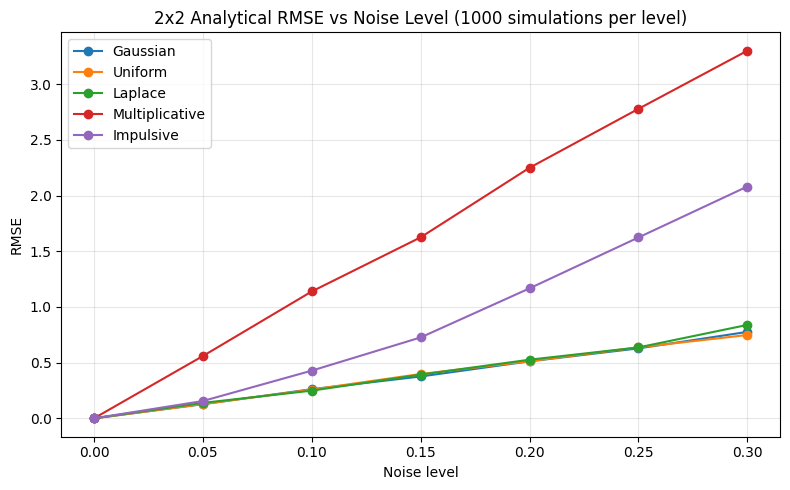

In [13]:
plot_metric_vs_noise(
    analytical_noise_2x2,
    metric="RMSE",
    title=(
        "2x2 Analytical RMSE vs Noise Level "
        "(1000 simulations per level)"
    )
)


## A5. Generate Independent 2×2 Train / Validation / Test Sets

In [14]:
(
    d_train_2x2, m_train_2x2,
    d_val_2x2, m_val_2x2,
    d_test_2x2, m_test_2x2
) = make_independent_datasets(
    K=K_2x2,
    n_cells=4,
    n_train=21000,
    n_val=4500,
    n_test=4500,
    seed=SEED + 2000
)

print("\nTraining:", m_train_2x2.shape)
print("Validation:", m_val_2x2.shape)
print("Testing:", m_test_2x2.shape)


Train / Validation overlap: 0
Train / Test overlap: 0
Validation / Test overlap: 0

Training: (21000, 4)
Validation: (4500, 4)
Testing: (4500, 4)


## A6. 2×2 Pre-processing - Fit Scalers on Training Data

In [15]:
x_scaler_2x2 = StandardScaler()
y_scaler_2x2 = StandardScaler()

d_train_2x2_s = x_scaler_2x2.fit_transform(
    d_train_2x2
)

d_val_2x2_s = x_scaler_2x2.transform(
    d_val_2x2
)

d_test_2x2_s = x_scaler_2x2.transform(
    d_test_2x2
)

m_train_2x2_s = y_scaler_2x2.fit_transform(
    m_train_2x2
)

m_val_2x2_s = y_scaler_2x2.transform(
    m_val_2x2
)


## A7. 2×2 MLP Architecture - T1,T2,T3,T4 → S1,S2,S3,S4

In [16]:
mlp_2x2 = Sequential([
    Input(
        shape=(4,),
        name="Travel_Times_T1_T2_T3_T4"
    ),

    Dense(
        64,
        activation="relu",
        name="Hidden_Layer_1"
    ),

    Dense(
        64,
        activation="relu",
        name="Hidden_Layer_2"
    ),

    Dense(
        4,
        activation="linear",
        name="Slowness_S1_S2_S3_S4"
    )
])

mlp_2x2.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Slowness_S1_S2_S3_S4 (Dense)    │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,740 (18.52 KB)

 Trainable params: 4,740 (18.52 KB)

 Non-trainable params: 0 (0.00 B)

## A8. Compile the 2×2 MLP

In [17]:
mlp_2x2.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss="mse",
    metrics=["mae"]
)


## A9. Train the 2×2 MLP

In [18]:
early_stop_2x2 = EarlyStopping(
    monitor="val_loss",
    patience=25,
    restore_best_weights=True
)

start = time.perf_counter()

history_2x2 = mlp_2x2.fit(
    d_train_2x2_s,
    m_train_2x2_s,
    validation_data=(
        d_val_2x2_s,
        m_val_2x2_s
    ),
    epochs=300,
    batch_size=128,
    callbacks=[early_stop_2x2],
    verbose=1
)

training_time_2x2 = (
    time.perf_counter() - start
)

print("2x2 training time:",
      training_time_2x2)


Epoch 1/300
165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.1778 - mae: 0.2442 - val_loss: 0.0035 - val_mae: 0.0463
Epoch 2/300
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0025 - mae: 0.0387 - val_loss: 0.0018 - val_mae: 0.0331
Epoch 3/300
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0015 - mae: 0.0298 - val_loss: 0.0012 - val_mae: 0.0266
Epoch 4/300
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 9.6457e-04 - mae: 0.0243 - val_loss: 8.2574e-04 - val_mae: 0.0224
Epoch 5/300
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.9115e-04 - mae: 0.0206 - val_loss: 6.1724e-04 - val_mae: 0.0194
Epoch 6/300
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 5.3355e-04 - mae: 0.0181 - val_loss: 4.9488e-04 - val_mae: 0.0174
Epoch 7/300
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.3487e-04 - mae: 0.0164 - val_loss: 4.1241e-04 - val_mae: 0.0159
Epoch 8/300
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 3.6598e-04 - mae: 0.0150 - val_loss: 3.5886e-04 - val_mae: 0.0149
Epoch 9

## A10. Plot 2×2 Training and Validation Loss

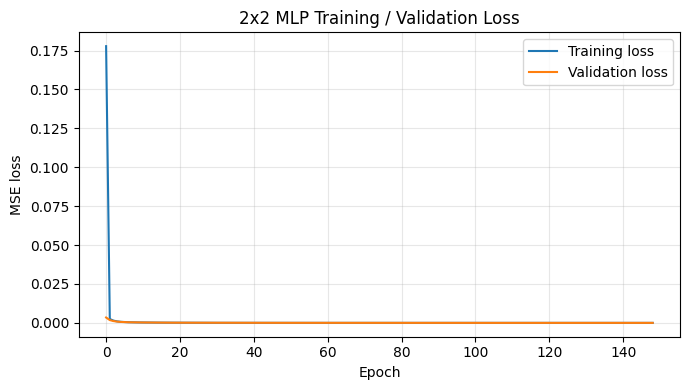

In [19]:
plt.figure(figsize=(7,4))

plt.plot(
    history_2x2.history["loss"],
    label="Training loss"
)

plt.plot(
    history_2x2.history["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("2x2 MLP Training / Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## A11. Clean 2×2 Analytical vs MLP Test Results

In [20]:
# This code snippet was generated with assistance from ChatGPT.
# Analytical

start = time.perf_counter()

m_test_analytic_2x2 = (
    analytical_reconstruction_batch(
        K_2x2,
        d_test_2x2
    )
)

analytic_time_2x2 = (
    time.perf_counter() - start
)

# MLP
start = time.perf_counter()

m_test_mlp_2x2_s = mlp_2x2.predict(
    d_test_2x2_s,
    verbose=0
)

mlp_time_2x2 = (
    time.perf_counter() - start
)

m_test_mlp_2x2 = (
    y_scaler_2x2.inverse_transform(
        m_test_mlp_2x2_s
    )
)

metrics_analytic_2x2 = (
    reconstruction_metrics(
        m_test_2x2,
        m_test_analytic_2x2
    )
)

metrics_mlp_2x2 = (
    reconstruction_metrics(
        m_test_2x2,
        m_test_mlp_2x2
    )
)

clean_2x2 = pd.DataFrame([
    {
        "Grid":"2x2",
        "Method":"Analytical",
        **metrics_analytic_2x2,
        "Mean Prediction Time (s)":
            analytic_time_2x2 / len(m_test_2x2),
        "Training Time (s)":0.0
    },
    {
        "Grid":"2x2",
        "Method":"MLP",
        **metrics_mlp_2x2,
        "Mean Prediction Time (s)":
            mlp_time_2x2 / len(m_test_2x2),
        "Training Time (s)":
            training_time_2x2
    }
])

display(clean_2x2)


,Grid,Method,MSE,RMSE,Relative Error (%),Accuracy (%),Mean Prediction Time (s),Training Time (s)
0,2x2,Analytical,1.063657e-13,3.261375e-07,0.000005,99.999995,2.137349e-07,0.000000
1,2x2,MLP,2.997397e-05,5.474849e-03,0.090536,99.909464,8.987875e-05,98.094652


## A12. 2×2 All Five Noise Types for Analytical and MLP

In [21]:
# This code snippet was generated with assistance from ChatGPT.

noise_rows_2x2 = []

M_noise_true_2x2 = (
    m_test_2x2[:1000].astype(float)
)

D_noise_clean_2x2 = (
    forward_model_batch(
        K_2x2,
        M_noise_true_2x2
    )
)

for noise_index, noise_type in enumerate(
    NOISE_TYPES
):
    for level_index, level in enumerate(
        NOISE_LEVELS
    ):

        rng = np.random.default_rng(
            SEED
            + 210000
            + noise_index*10000
            + level_index*100
        )

        D_noisy = add_noise_batch(
            D_noise_clean_2x2,
            noise_type,
            float(level),
            rng
        )

        # Analytical
        start = time.perf_counter()

        M_a = analytical_reconstruction_batch(
            K_2x2,
            D_noisy
        )

        elapsed_a = (
            time.perf_counter() - start
        )

        met_a = reconstruction_metrics(
            M_noise_true_2x2,
            M_a
        )

        noise_rows_2x2.append({
            "Grid":"2x2",
            "Method":"Analytical",
            "Noise Type":noise_type,
            "Noise Level":float(level),
            "Simulations":1000,
            **met_a,
            "Mean Prediction Time (s)":
                elapsed_a / 1000
        })

        # MLP
        D_noisy_s = x_scaler_2x2.transform(
            D_noisy
        )

        start = time.perf_counter()

        M_nn_s = mlp_2x2.predict(
            D_noisy_s,
            verbose=0
        )

        elapsed_nn = (
            time.perf_counter() - start
        )

        M_nn = y_scaler_2x2.inverse_transform(
            M_nn_s
        )

        met_nn = reconstruction_metrics(
            M_noise_true_2x2,
            M_nn
        )

        noise_rows_2x2.append({
            "Grid":"2x2",
            "Method":"MLP",
            "Noise Type":noise_type,
            "Noise Level":float(level),
            "Simulations":1000,
            **met_nn,
            "Mean Prediction Time (s)":
                elapsed_nn / 1000
        })

noise_2x2 = pd.DataFrame(
    noise_rows_2x2
)

display(noise_2x2)


,Grid,Method,Noise Type,Noise Level,Simulations,MSE,RMSE,Relative Error (%),Accuracy (%),Mean Prediction Time (s)
0,2x2,Analytical,Gaussian,0.00,1000,0.000000,0.000000,0.000000,100.000000,2.628540e-07
1,2x2,MLP,Gaussian,0.00,1000,0.000030,0.005502,0.091503,99.908497,1.401920e-04
2,2x2,Analytical,Gaussian,0.05,1000,0.017864,0.133657,1.998411,98.001589,1.215840e-07
3,2x2,MLP,Gaussian,0.05,1000,0.017856,0.133627,1.998463,98.001537,1.206284e-04
4,2x2,Analytical,Gaussian,0.10,1000,0.064537,0.254041,3.889975,96.110025,1.156620e-07
...,...,...,...,...,...,...,...,...,...,...
65,2x2,MLP,Impulsive,0.20,1000,1.538130,1.240214,12.876258,87.123742,1.260740e-04
66,2x2,Analytical,Impulsive,0.25,1000,2.703431,1.644211,17.904273,82.095727,1.232160e-07
67,2x2,MLP,Impulsive,0.25,1000,2.689031,1.639827,17.900896,82.099104,1.235660e-04
68,2x2,Analytical,Impulsive,0.30,1000,4.116880,2.029009,24.525597,75.474403,1.369080e-07


## A13. Challenging / Weird 2×2 Slowness Cases

In [22]:
challenging_cases_2x2 = {
    "Nearly equal cells": np.array([4.95, 5.00, 5.05, 5.10]),
    "One high peak": np.array([2.0, 2.0, 8.0, 2.0]),
    "Two close peaks": np.array([2.0, 7.5, 7.8, 2.0]),
    "High contrast": np.array([0.7, 9.5, 1.0, 9.0]),
}

weird_case_rows = []

for case_name, true_m in challenging_cases_2x2.items():

    d_case = forward_model(
        K_2x2,
        true_m
    )

    # Analytical reconstruction
    analytic_hat = analytical_reconstruction(
        K_2x2,
        d_case
    )

    # MLP reconstruction
    d_case_scaled = x_scaler_2x2.transform(
        d_case.reshape(1, -1)
    )

    mlp_hat_scaled = mlp_2x2.predict(
        d_case_scaled,
        verbose=0
    )

    mlp_hat = y_scaler_2x2.inverse_transform(
        mlp_hat_scaled
    )[0]

    weird_case_rows.append({
        "Case": case_name,
        "Method": "Analytical",
        **reconstruction_metrics(
            true_m,
            analytic_hat
        )
    })

    weird_case_rows.append({
        "Case": case_name,
        "Method": "MLP",
        **reconstruction_metrics(
            true_m,
            mlp_hat
        )
    })

weird_cases_2x2 = pd.DataFrame(
    weird_case_rows
)

display(weird_cases_2x2)


,Case,Method,MSE,RMSE,Relative Error (%),Accuracy (%)
0,Nearly equal cells,Analytical,1.183291e-30,1.087792e-15,2.164626e-14,100.000000
1,Nearly equal cells,MLP,7.625446e-06,2.761421e-03,5.495025e-02,99.945050
2,One high peak,Analytical,0.000000e+00,0.000000e+00,0.000000e+00,100.000000
3,One high peak,MLP,4.245070e-05,6.515420e-03,1.494740e-01,99.850526
4,Two close peaks,Analytical,1.972152e-31,4.440892e-16,7.941251e-15,100.000000
5,Two close peaks,MLP,1.981280e-05,4.451157e-03,7.959608e-02,99.920404
6,High contrast,Analytical,1.109336e-31,3.330669e-16,5.068332e-15,100.000000
7,High contrast,MLP,1.534382e-05,3.917119e-03,5.960741e-02,99.940393


## A14. How Much Noise Can Be Added Before the Peak Becomes Difficult to See?

In [23]:
peak_model_2x2 = np.array([
    2.0, 2.0,
    8.0, 2.0
])

true_peak_cell = int(
    np.argmax(peak_model_2x2)
)

# This code snippet was generated with assistance from ChatGPT.

peak_detection_rows = []

for noise_type in NOISE_TYPES:

    for level_index, level in enumerate(
        NOISE_LEVELS
    ):


        D_peak_clean = np.repeat(
            forward_model(
                K_2x2,
                peak_model_2x2
            ).reshape(1, -1),
            N_MONTE_CARLO,
            axis=0
        )

        rng = np.random.default_rng(
            SEED
            + 500000
            + 10000 * NOISE_TYPES.index(noise_type)
            + 100 * level_index
        )

        D_peak_noisy = add_noise_batch(
            D_peak_clean,
            noise_type,
            float(level),
            rng
        )

        # Analytical
        A_hat = analytical_reconstruction_batch(
            K_2x2,
            D_peak_noisy
        )

        analytical_detected = (
            np.mean(
                np.argmax(A_hat, axis=1)
                == true_peak_cell
            ) * 100.0
        )

        # MLP
        D_peak_noisy_scaled = (
            x_scaler_2x2.transform(
                D_peak_noisy
            )
        )

        NN_hat_scaled = mlp_2x2.predict(
            D_peak_noisy_scaled,
            verbose=0
        )

        NN_hat = y_scaler_2x2.inverse_transform(
            NN_hat_scaled
        )

        mlp_detected = (
            np.mean(
                np.argmax(NN_hat, axis=1)
                == true_peak_cell
            ) * 100.0
        )

        peak_detection_rows.extend([
            {
                "Noise Type": noise_type,
                "Noise Level": float(level),
                "Method": "Analytical",
                "Peak Detected (%)": analytical_detected
            },
            {
                "Noise Type": noise_type,
                "Noise Level": float(level),
                "Method": "MLP",
                "Peak Detected (%)": mlp_detected
            }
        ])

peak_detection_2x2 = pd.DataFrame(
    peak_detection_rows
)

display(peak_detection_2x2)


,Noise Type,Noise Level,Method,Peak Detected (%)
0,Gaussian,0.00,Analytical,100.0
1,Gaussian,0.00,MLP,100.0
2,Gaussian,0.05,Analytical,100.0
3,Gaussian,0.05,MLP,100.0
4,Gaussian,0.10,Analytical,100.0
...,...,...,...,...
65,Impulsive,0.20,MLP,98.1
66,Impulsive,0.25,Analytical,94.5
67,Impulsive,0.25,MLP,94.5
68,Impulsive,0.30,Analytical,90.1


## A15. Plot Peak Detectability vs Noise Level

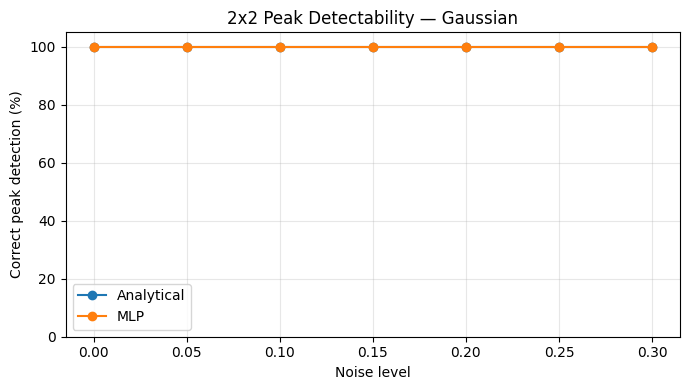

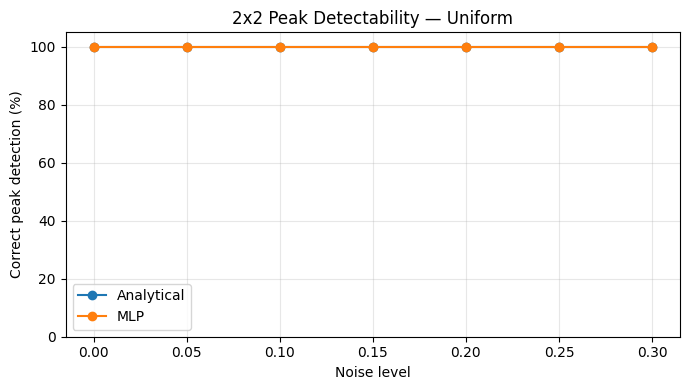

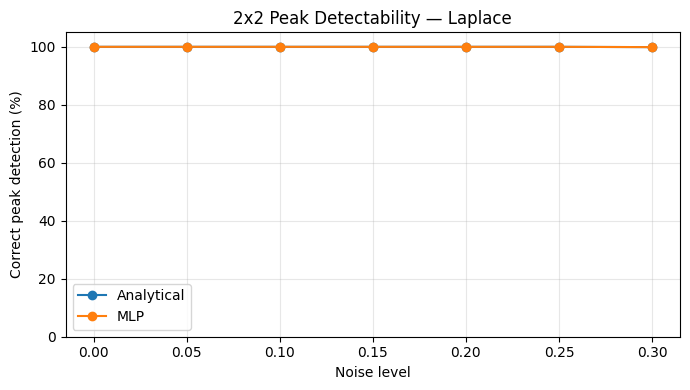

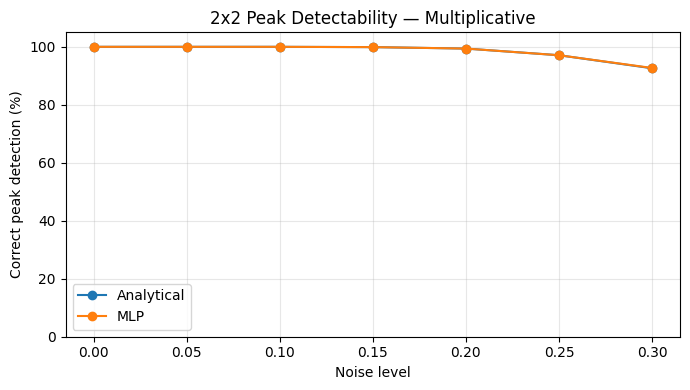

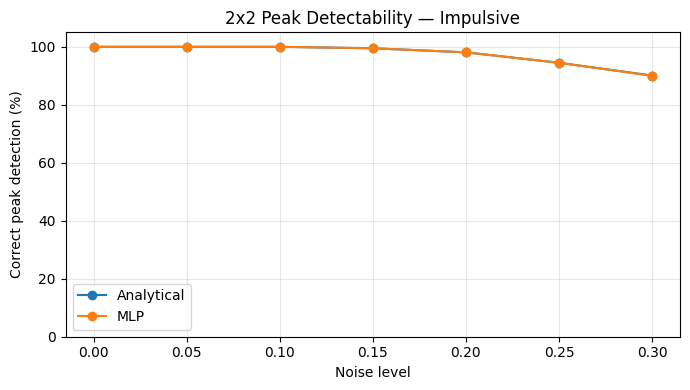

In [24]:
for noise_type in NOISE_TYPES:

    plt.figure(figsize=(7,4))

    for method in [
        "Analytical",
        "MLP"
    ]:

        sub = peak_detection_2x2[
            (peak_detection_2x2["Noise Type"] == noise_type)
            &
            (peak_detection_2x2["Method"] == method)
        ]

        plt.plot(
            sub["Noise Level"],
            sub["Peak Detected (%)"],
            marker="o",
            label=method
        )

    plt.xlabel("Noise level")
    plt.ylabel(
        "Correct peak detection (%)"
    )
    plt.ylim(0, 105)
    plt.title(
        f"2x2 Peak Detectability — {noise_type}"
    )
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# PART B - 3×3 TOY MODEL

## B1. The 3×3 Model

In [25]:
K_3x3, rays_3x3 = build_problem(3)

print("3x3 K shape:", K_3x3.shape)
print("Rank:", np.linalg.matrix_rank(K_3x3))
print("Condition number:",
      np.linalg.cond(K_3x3))


3x3 K shape: (54, 9)
Rank: 9
Condition number: 2.9122502960766004


## B2. Exact 3×3 Analytical Reconstruction Without Noise

In [26]:
rng = np.random.default_rng(SEED + 3001)

m_true_3x3 = rng.uniform(
    SLOWNESS_MIN,
    SLOWNESS_MAX,
    size=9
)

d_clean_3x3 = forward_model(
    K_3x3,
    m_true_3x3
)

m_hat_3x3 = analytical_reconstruction(
    K_3x3,
    d_clean_3x3
)

print(
    reconstruction_metrics(
        m_true_3x3,
        m_hat_3x3
    )
)


{'MSE': 6.055055267644336e-29, 'RMSE': 7.781423563618893e-15, 'Relative Error (%)': np.float64(1.344933299927264e-13), 'Accuracy (%)': np.float64(99.99999999999987)}


## B3. 3×3 Analytical Error vs Noise - 1,000 Simulations

In [27]:
analytical_noise_3x3 = analytical_monte_carlo(
    n=3,
    K=K_3x3,
    n_simulations=1000
)

display(analytical_noise_3x3)


,Grid,Noise Type,Noise Level,Simulations,MSE,RMSE,Relative Error (%),Accuracy (%),Mean Reconstruction Time (s)
0,3x3,Gaussian,0.00,1000,3.052885e-29,5.525292e-15,9.158209e-14,100.000000,5.024600e-07
1,3x3,Gaussian,0.05,1000,8.134701e-03,9.019258e-02,1.472373e+00,98.527627,5.832510e-07
2,3x3,Gaussian,0.10,1000,3.284125e-02,1.812215e-01,2.966697e+00,97.033303,1.090107e-06
3,3x3,Gaussian,0.15,1000,7.359359e-02,2.712814e-01,4.452263e+00,95.547737,1.246780e-06
4,3x3,Gaussian,0.20,1000,1.358454e-01,3.685721e-01,6.025697e+00,93.974303,4.695500e-07
5,3x3,Gaussian,0.25,1000,2.039108e-01,4.515649e-01,7.371331e+00,92.628669,4.481240e-07
6,3x3,Gaussian,0.30,1000,2.934740e-01,5.417324e-01,8.866690e+00,91.133310,5.353610e-07
7,3x3,Uniform,0.00,1000,2.973940e-29,5.453384e-15,9.112553e-14,100.000000,4.284970e-07
8,3x3,Uniform,0.05,1000,8.397207e-03,9.163627e-02,1.498591e+00,98.501409,4.237530e-07
9,3x3,Uniform,0.10,1000,3.212074e-02,1.792226e-01,2.948374e+00,97.051626,4.333440e-07


## B4. Plot 3×3 Analytical RMSE vs Noise Level

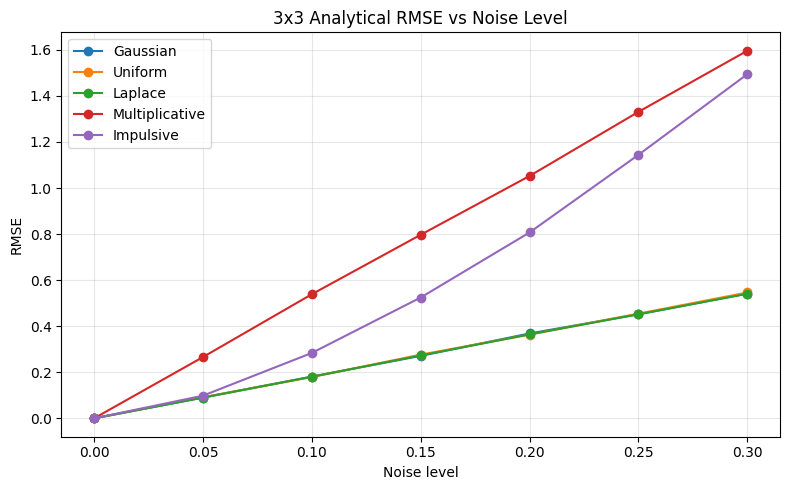

In [28]:
plot_metric_vs_noise(
    analytical_noise_3x3,
    "RMSE",
    "3x3 Analytical RMSE vs Noise Level"
)


## B5. Independent 3×3 Train / Validation / Test Sets

In [29]:
(
    d_train_3x3, m_train_3x3,
    d_val_3x3, m_val_3x3,
    d_test_3x3, m_test_3x3
) = make_independent_datasets(
    K=K_3x3,
    n_cells=9,
    n_train=22000,
    n_val=4000,
    n_test=4000,
    seed=SEED + 3000
)


Train / Validation overlap: 0
Train / Test overlap: 0
Validation / Test overlap: 0


## B6. 3×3 Pre-processing

In [30]:
x_scaler_3x3 = StandardScaler()
y_scaler_3x3 = StandardScaler()

d_train_3x3_s = x_scaler_3x3.fit_transform(
    d_train_3x3
)
d_val_3x3_s = x_scaler_3x3.transform(
    d_val_3x3
)
d_test_3x3_s = x_scaler_3x3.transform(
    d_test_3x3
)

m_train_3x3_s = y_scaler_3x3.fit_transform(
    m_train_3x3
)
m_val_3x3_s = y_scaler_3x3.transform(
    m_val_3x3
)


## B7. 3×3 MLP Architecture

In [31]:
mlp_3x3 = Sequential([
    Input(
        shape=(K_3x3.shape[0],),
        name="Travel_Time_Input"
    ),

    Dense(
        128,
        activation="relu",
        name="Hidden_Layer_1"
    ),

    Dense(
        128,
        activation="relu",
        name="Hidden_Layer_2"
    ),

    Dense(
        64,
        activation="relu",
        name="Hidden_Layer_3"
    ),

    Dense(
        9,
        activation="linear",
        name="Slowness_Output_9_Cells"
    )
])

mlp_3x3.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 128)            │         7,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_3 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Slowness_Output_9_Cells (Dense) │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,393 (126.54 KB)

 Trainable params: 32,393 (126.54 KB)

 Non-trainable params: 0 (0.00 B)

## B8. Compile the 3×3 MLP

In [32]:
mlp_3x3.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss="mse",
    metrics=["mae"]
)


## B9. Train the 3×3 MLP

In [33]:
early_stop_3x3 = EarlyStopping(
    monitor="val_loss",
    patience=25,
    restore_best_weights=True
)

start = time.perf_counter()

history_3x3 = mlp_3x3.fit(
    d_train_3x3_s,
    m_train_3x3_s,
    validation_data=(
        d_val_3x3_s,
        m_val_3x3_s
    ),
    epochs=350,
    batch_size=128,
    callbacks=[early_stop_3x3],
    verbose=1
)

training_time_3x3 = (
    time.perf_counter() - start
)

print("3x3 training time:",
      training_time_3x3)


Epoch 1/350
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0911 - mae: 0.1760 - val_loss: 0.0082 - val_mae: 0.0714
Epoch 2/350
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0057 - mae: 0.0595 - val_loss: 0.0041 - val_mae: 0.0509
Epoch 3/350
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0034 - mae: 0.0457 - val_loss: 0.0028 - val_mae: 0.0423
Epoch 4/350
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0023 - mae: 0.0376 - val_loss: 0.0019 - val_mae: 0.0346
Epoch 5/350
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0017 - mae: 0.0321 - val_loss: 0.0015 - val_mae: 0.0308
Epoch 6/350
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0012 - mae: 0.0273 - val_loss: 0.0012 - val_mae: 0.0275
Epoch 7/350
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.8536e-04 - mae: 0.0235 - val_loss: 7.8489e-04 - val_mae: 0.0221
Epoch 8/350
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.5858e-04 - mae: 0.0202 - val_loss: 5.2960e-04 - val_mae: 0.0182
Epoch 9/350
172/172 ━━━━━━━━━━━

## B10. Plot 3×3 Training and Validation Loss

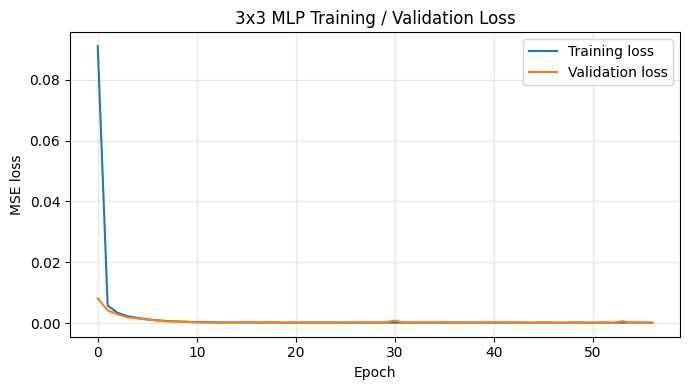

In [34]:
plt.figure(figsize=(7,4))
plt.plot(
    history_3x3.history["loss"],
    label="Training loss"
)
plt.plot(
    history_3x3.history["val_loss"],
    label="Validation loss"
)
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("3x3 MLP Training / Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## B11. Clean 3×3 Analytical vs MLP Test Results

In [35]:
# Generated with ChatGPT assistance and adapted for this project.

start = time.perf_counter()

m_test_analytic_3x3 = (
    analytical_reconstruction_batch(
        K_3x3,
        d_test_3x3
    )
)

analytic_time_3x3 = (
    time.perf_counter() - start
)

start = time.perf_counter()

m_test_mlp_3x3_s = mlp_3x3.predict(
    d_test_3x3_s,
    verbose=0
)

mlp_time_3x3 = (
    time.perf_counter() - start
)

m_test_mlp_3x3 = (
    y_scaler_3x3.inverse_transform(
        m_test_mlp_3x3_s
    )
)

clean_3x3 = pd.DataFrame([
    {
        "Grid":"3x3",
        "Method":"Analytical",
        **reconstruction_metrics(
            m_test_3x3,
            m_test_analytic_3x3
        ),
        "Mean Prediction Time (s)":
            analytic_time_3x3/len(m_test_3x3),
        "Training Time (s)":0.0
    },
    {
        "Grid":"3x3",
        "Method":"MLP",
        **reconstruction_metrics(
            m_test_3x3,
            m_test_mlp_3x3
        ),
        "Mean Prediction Time (s)":
            mlp_time_3x3/len(m_test_3x3),
        "Training Time (s)":
            training_time_3x3
    }
])

display(clean_3x3)


,Grid,Method,MSE,RMSE,Relative Error (%),Accuracy (%),Mean Prediction Time (s),Training Time (s)
0,3x3,Analytical,1.857238e-14,1.362805e-07,0.000002,99.999998,0.000001,0.000000
1,3x3,MLP,3.212209e-04,1.792264e-02,0.293957,99.706043,0.000084,49.057149


## B12. 3×3 All Five Noise Types - Analytical and MLP

In [36]:
# Generated with ChatGPT assistance and adapted for this project.

noise_rows_3x3 = []

M_noise_true_3x3 = (
    m_test_3x3[:1000].astype(float)
)

D_noise_clean_3x3 = (
    forward_model_batch(
        K_3x3,
        M_noise_true_3x3
    )
)

for noise_index, noise_type in enumerate(NOISE_TYPES):
    for level_index, level in enumerate(NOISE_LEVELS):

        rng = np.random.default_rng(
            SEED + 310000
            + noise_index*10000
            + level_index*100
        )

        D_noisy = add_noise_batch(
            D_noise_clean_3x3,
            noise_type,
            float(level),
            rng
        )

        start = time.perf_counter()
        M_a = analytical_reconstruction_batch(
            K_3x3,
            D_noisy
        )
        elapsed_a = time.perf_counter() - start

        noise_rows_3x3.append({
            "Grid":"3x3",
            "Method":"Analytical",
            "Noise Type":noise_type,
            "Noise Level":float(level),
            "Simulations":1000,
            **reconstruction_metrics(
                M_noise_true_3x3,
                M_a
            ),
            "Mean Prediction Time (s)":
                elapsed_a/1000
        })

        D_noisy_s = x_scaler_3x3.transform(
            D_noisy
        )

        start = time.perf_counter()
        M_nn_s = mlp_3x3.predict(
            D_noisy_s,
            verbose=0
        )
        elapsed_nn = time.perf_counter() - start

        M_nn = y_scaler_3x3.inverse_transform(
            M_nn_s
        )

        noise_rows_3x3.append({
            "Grid":"3x3",
            "Method":"MLP",
            "Noise Type":noise_type,
            "Noise Level":float(level),
            "Simulations":1000,
            **reconstruction_metrics(
                M_noise_true_3x3,
                M_nn
            ),
            "Mean Prediction Time (s)":
                elapsed_nn/1000
        })

noise_3x3 = pd.DataFrame(noise_rows_3x3)
display(noise_3x3)


,Grid,Method,Noise Type,Noise Level,Simulations,MSE,RMSE,Relative Error (%),Accuracy (%),Mean Prediction Time (s)
0,3x3,Analytical,Gaussian,0.00,1000,3.110850e-29,5.577500e-15,9.222510e-14,100.000000,5.226130e-07
1,3x3,MLP,Gaussian,0.00,1000,3.367765e-04,1.835147e-02,2.970812e-01,99.702919,1.590840e-04
2,3x3,Analytical,Gaussian,0.05,1000,8.413453e-03,9.172488e-02,1.491939e+00,98.508061,3.507440e-07
3,3x3,MLP,Gaussian,0.05,1000,2.122630e-02,1.456925e-01,2.367422e+00,97.632578,1.216889e-04
4,3x3,Analytical,Gaussian,0.10,1000,3.396452e-02,1.842947e-01,2.982640e+00,97.017360,3.465830e-07
...,...,...,...,...,...,...,...,...,...,...
65,3x3,MLP,Impulsive,0.20,1000,1.576320e+00,1.255516e+00,1.972959e+01,80.270410,1.203313e-04
66,3x3,Analytical,Impulsive,0.25,1000,1.326110e+00,1.151568e+00,1.831931e+01,81.680689,3.687630e-07
67,3x3,MLP,Impulsive,0.25,1000,2.910660e+00,1.706066e+00,2.672368e+01,73.276323,1.249497e-04
68,3x3,Analytical,Impulsive,0.30,1000,2.332883e+00,1.527378e+00,2.429154e+01,75.708455,4.382240e-07


## B13. 3×3 MLP Input and Output Structure

In [37]:
input_labels_3x3 = [
    f"T{i+1}" for i in range(K_3x3.shape[0])
]

output_labels_3x3 = [
    f"S{i+1}" for i in range(9)
]

print("3x3 MLP inputs:")
print(input_labels_3x3)

print("\n3x3 MLP outputs:")
print(output_labels_3x3)

print(
    f"\nMapping: T1...T{K_3x3.shape[0]} "
    "→ MLP → S1...S9"
)


3x3 MLP inputs:
['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 'T11', 'T12', 'T13', 'T14', 'T15', 'T16', 'T17', 'T18', 'T19', 'T20', 'T21', 'T22', 'T23', 'T24', 'T25', 'T26', 'T27', 'T28', 'T29', 'T30', 'T31', 'T32', 'T33', 'T34', 'T35', 'T36', 'T37', 'T38', 'T39', 'T40', 'T41', 'T42', 'T43', 'T44', 'T45', 'T46', 'T47', 'T48', 'T49', 'T50', 'T51', 'T52', 'T53', 'T54']

3x3 MLP outputs:
['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']

Mapping: T1...T54 → MLP → S1...S9


## B14. Challenging / Weird 3×3 Slowness Cases

In [38]:
# Several structured 3x3 cases to test more than random average examples.

base_3 = np.full((3,3), 2.0)

case_3_equal = np.full((3,3), 5.0)

case_3_one_peak = base_3.copy()
case_3_one_peak[1,1] = 8.0

case_3_two_peaks = base_3.copy()
case_3_two_peaks[0,2] = 7.5
case_3_two_peaks[2,0] = 7.8

case_3_high_contrast = np.array([
    [0.7, 9.5, 0.8],
    [9.0, 1.0, 9.2],
    [0.9, 9.4, 0.6]
])

challenging_cases_3x3 = {
    "Nearly equal cells": case_3_equal.ravel(),
    "One central high peak": case_3_one_peak.ravel(),
    "Two separated peaks": case_3_two_peaks.ravel(),
    "High contrast": case_3_high_contrast.ravel(),
}

rows_3x3 = []

for case_name, true_m in challenging_cases_3x3.items():

    d_case = forward_model(
        K_3x3,
        true_m
    )

    a_hat = analytical_reconstruction(
        K_3x3,
        d_case
    )

    d_case_s = x_scaler_3x3.transform(
        d_case.reshape(1,-1)
    )

    n_hat_s = mlp_3x3.predict(
        d_case_s,
        verbose=0
    )

    n_hat = y_scaler_3x3.inverse_transform(
        n_hat_s
    )[0]

    rows_3x3.extend([
        {
            "Case":case_name,
            "Method":"Analytical",
            **reconstruction_metrics(true_m, a_hat)
        },
        {
            "Case":case_name,
            "Method":"MLP",
            **reconstruction_metrics(true_m, n_hat)
        }
    ])

weird_cases_3x3 = pd.DataFrame(rows_3x3)

display(weird_cases_3x3)


,Case,Method,MSE,RMSE,Relative Error (%),Accuracy (%)
0,Nearly equal cells,Analytical,1.016754e-29,3.188658e-15,6.377316e-14,100.000000
1,Nearly equal cells,MLP,1.419137e-05,3.767144e-03,7.534287e-02,99.924657
2,One central high peak,Analytical,6.376626e-30,2.525198e-15,7.731809e-14,100.000000
3,One central high peak,MLP,6.378980e-04,2.525664e-02,7.733236e-01,99.226676
4,Two separated peaks,Analytical,1.258343e-29,3.547313e-15,8.834907e-14,100.000000
5,Two separated peaks,MLP,4.107911e-04,2.026798e-02,5.047927e-01,99.495207
6,High contrast,Analytical,5.784706e-29,7.605726e-15,1.223921e-13,100.000000
7,High contrast,MLP,5.441142e-04,2.332626e-02,3.753683e-01,99.624632


## B15. 3×3 Peak Detectability vs Noise Level

In [39]:
# Generated with ChatGPT assistance and adapted for this project.
# One high-slowness cell in the centre of a 3x3 grid.

peak_grid_3x3 = np.full((3,3), 2.0)
peak_grid_3x3[1,1] = 8.0

peak_model_3x3 = peak_grid_3x3.ravel()

true_peak_cell_3x3 = int(
    np.argmax(peak_model_3x3)
)

peak_rows_3x3 = []

for noise_type in NOISE_TYPES:

    for level_index, level in enumerate(NOISE_LEVELS):

        D_clean = np.repeat(
            forward_model(
                K_3x3,
                peak_model_3x3
            ).reshape(1,-1),
            N_MONTE_CARLO,
            axis=0
        )

        rng = np.random.default_rng(
            SEED + 530000
            + 10000 * NOISE_TYPES.index(noise_type)
            + 100 * level_index
        )

        D_noisy = add_noise_batch(
            D_clean,
            noise_type,
            float(level),
            rng
        )

        # Analytical
        A_hat = analytical_reconstruction_batch(
            K_3x3,
            D_noisy
        )

        a_detect = np.mean(
            np.argmax(A_hat, axis=1)
            == true_peak_cell_3x3
        ) * 100.0

        # MLP
        D_noisy_s = x_scaler_3x3.transform(
            D_noisy
        )

        N_hat_s = mlp_3x3.predict(
            D_noisy_s,
            verbose=0
        )

        N_hat = y_scaler_3x3.inverse_transform(
            N_hat_s
        )

        n_detect = np.mean(
            np.argmax(N_hat, axis=1)
            == true_peak_cell_3x3
        ) * 100.0

        peak_rows_3x3.extend([
            {
                "Grid":"3x3",
                "Noise Type":noise_type,
                "Noise Level":float(level),
                "Method":"Analytical",
                "Peak Detected (%)":a_detect
            },
            {
                "Grid":"3x3",
                "Noise Type":noise_type,
                "Noise Level":float(level),
                "Method":"MLP",
                "Peak Detected (%)":n_detect
            }
        ])

peak_detection_3x3 = pd.DataFrame(
    peak_rows_3x3
)

display(peak_detection_3x3)


,Grid,Noise Type,Noise Level,Method,Peak Detected (%)
0,3x3,Gaussian,0.00,Analytical,100.0
1,3x3,Gaussian,0.00,MLP,100.0
2,3x3,Gaussian,0.05,Analytical,100.0
3,3x3,Gaussian,0.05,MLP,100.0
4,3x3,Gaussian,0.10,Analytical,100.0
...,...,...,...,...,...
65,3x3,Impulsive,0.20,MLP,99.8
66,3x3,Impulsive,0.25,Analytical,100.0
67,3x3,Impulsive,0.25,MLP,99.0
68,3x3,Impulsive,0.30,Analytical,100.0


# PART C - 4×4 TOY MODEL

## C1. The 4×4 Model

In [40]:
K_4x4, rays_4x4 = build_problem(4)

print("4x4 K shape:", K_4x4.shape)
print("Rank:", np.linalg.matrix_rank(K_4x4))
print("Condition number:",
      np.linalg.cond(K_4x4))


4x4 K shape: (96, 16)
Rank: 16
Condition number: 3.5557504158989057


## C2. 4×4 Analytical Reconstruction Without Noise

In [41]:
rng = np.random.default_rng(SEED + 4001)

m_true_4x4 = rng.uniform(
    SLOWNESS_MIN,
    SLOWNESS_MAX,
    size=16
)

d_clean_4x4 = forward_model(
    K_4x4,
    m_true_4x4
)

m_hat_4x4 = analytical_reconstruction(
    K_4x4,
    d_clean_4x4
)

print(
    reconstruction_metrics(
        m_true_4x4,
        m_hat_4x4
    )
)


{'MSE': 1.6307234025115603e-29, 'RMSE': 4.038221641405484e-15, 'Relative Error (%)': np.float64(9.0827780022308e-14), 'Accuracy (%)': np.float64(99.99999999999991)}


## C3. 4×4 Analytical Error vs Noise - 1,000 Simulations

In [42]:
analytical_noise_4x4 = analytical_monte_carlo(
    n=4,
    K=K_4x4,
    n_simulations=1000
)

display(analytical_noise_4x4)


,Grid,Noise Type,Noise Level,Simulations,MSE,RMSE,Relative Error (%),Accuracy (%),Mean Reconstruction Time (s)
0,4x4,Gaussian,0.00,1000,7.082151e-29,8.415552e-15,1.366374e-13,100.000000,8.540260e-07
1,4x4,Gaussian,0.05,1000,1.025424e-02,1.012632e-01,1.682104e+00,98.317896,7.044350e-07
2,4x4,Gaussian,0.10,1000,4.199383e-02,2.049240e-01,3.373279e+00,96.626721,6.473760e-07
3,4x4,Gaussian,0.15,1000,9.397387e-02,3.065516e-01,5.052992e+00,94.947008,6.509370e-07
4,4x4,Gaussian,0.20,1000,1.636511e-01,4.045381e-01,6.687797e+00,93.312203,6.562780e-07
5,4x4,Gaussian,0.25,1000,2.619182e-01,5.117795e-01,8.531707e+00,91.468293,7.341970e-07
6,4x4,Gaussian,0.30,1000,3.752067e-01,6.125412e-01,1.012481e+01,89.875188,6.591550e-07
7,4x4,Uniform,0.00,1000,7.424303e-29,8.616439e-15,1.395523e-13,100.000000,6.137080e-07
8,4x4,Uniform,0.05,1000,1.037630e-02,1.018641e-01,1.697255e+00,98.302745,6.123500e-07
9,4x4,Uniform,0.10,1000,4.203815e-02,2.050321e-01,3.381998e+00,96.618002,5.889300e-07


## C4. Plot 4×4 Analytical RMSE vs Noise Level

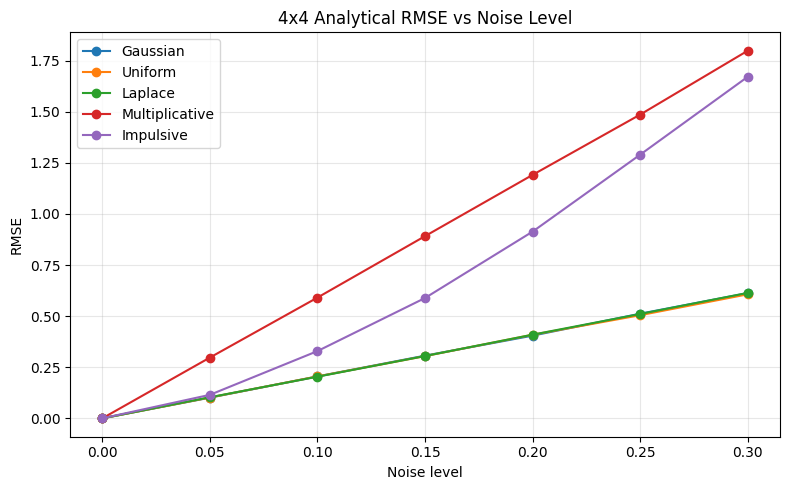

In [43]:
plot_metric_vs_noise(
    analytical_noise_4x4,
    "RMSE",
    "4x4 Analytical RMSE vs Noise Level"
)


## C5. Independent 4×4 Train / Validation / Test Sets

In [44]:
(
    d_train_4x4, m_train_4x4,
    d_val_4x4, m_val_4x4,
    d_test_4x4, m_test_4x4
) = make_independent_datasets(
    K=K_4x4,
    n_cells=16,
    n_train=30000,
    n_val=5000,
    n_test=5000,
    seed=SEED + 4000
)


Train / Validation overlap: 0
Train / Test overlap: 0
Validation / Test overlap: 0


## C6. 4×4 Pre-processing

In [45]:
x_scaler_4x4 = StandardScaler()
y_scaler_4x4 = StandardScaler()

d_train_4x4_s = x_scaler_4x4.fit_transform(
    d_train_4x4
)
d_val_4x4_s = x_scaler_4x4.transform(
    d_val_4x4
)
d_test_4x4_s = x_scaler_4x4.transform(
    d_test_4x4
)

m_train_4x4_s = y_scaler_4x4.fit_transform(
    m_train_4x4
)
m_val_4x4_s = y_scaler_4x4.transform(
    m_val_4x4
)


## C7. 4×4 MLP Architecture

In [46]:
mlp_4x4 = Sequential([
    Input(
        shape=(K_4x4.shape[0],),
        name="Travel_Time_Input"
    ),

    Dense(
        192,
        activation="relu",
        name="Hidden_Layer_1"
    ),

    Dense(
        128,
        activation="relu",
        name="Hidden_Layer_2"
    ),

    Dense(
        64,
        activation="relu",
        name="Hidden_Layer_3"
    ),

    Dense(
        16,
        activation="linear",
        name="Slowness_Output_16_Cells"
    )
])

mlp_4x4.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 192)            │        18,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_3 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Slowness_Output_16_Cells        │ (None, 16)             │         1,040 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,624 (205.56 KB)

 Trainable params: 52,624 (205.56 KB)

 Non-trainable params: 0 (0.00 B)

## C8. Compile the 4×4 MLP

In [47]:
mlp_4x4.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss="mse",
    metrics=["mae"]
)


## C9. Train the 4×4 MLP

In [48]:
early_stop_4x4 = EarlyStopping(
    monitor="val_loss",
    patience=25,
    restore_best_weights=True
)

start = time.perf_counter()

history_4x4 = mlp_4x4.fit(
    d_train_4x4_s,
    m_train_4x4_s,
    validation_data=(
        d_val_4x4_s,
        m_val_4x4_s
    ),
    epochs=400,
    batch_size=128,
    callbacks=[early_stop_4x4],
    verbose=1
)

training_time_4x4 = (
    time.perf_counter() - start
)

print("4x4 training time:",
      training_time_4x4)


Epoch 1/400
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1100 - mae: 0.1967 - val_loss: 0.0098 - val_mae: 0.0783
Epoch 2/400
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0062 - mae: 0.0618 - val_loss: 0.0042 - val_mae: 0.0513
Epoch 3/400
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0034 - mae: 0.0458 - val_loss: 0.0029 - val_mae: 0.0429
Epoch 4/400
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0020 - mae: 0.0354 - val_loss: 0.0016 - val_mae: 0.0321
Epoch 5/400
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0011 - mae: 0.0265 - val_loss: 9.0840e-04 - val_mae: 0.0239
Epoch 6/400
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.6815e-04 - mae: 0.0203 - val_loss: 5.1911e-04 - val_mae: 0.0179
Epoch 7/400
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.9173e-04 - mae: 0.0155 - val_loss: 3.9435e-04 - val_mae: 0.0157
Epoch 8/400
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.4344e-04 - mae: 0.0143 - val_loss: 3.5955e-04 - val_mae: 0.0153
Epoch 9/400
235/235 

## C10. Plot 4×4 Training and Validation Loss

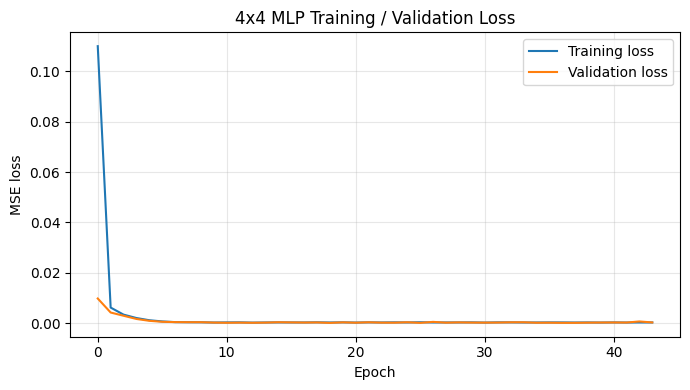

In [49]:
plt.figure(figsize=(7,4))
plt.plot(
    history_4x4.history["loss"],
    label="Training loss"
)
plt.plot(
    history_4x4.history["val_loss"],
    label="Validation loss"
)
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("4x4 MLP Training / Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## C11. 4×4 Analytical vs MLP Test Results

In [50]:
# Generated with ChatGPT assistance and adapted for this project.

start = time.perf_counter()

m_test_analytic_4x4 = (
    analytical_reconstruction_batch(
        K_4x4,
        d_test_4x4
    )
)

analytic_time_4x4 = (
    time.perf_counter() - start
)

start = time.perf_counter()

m_test_mlp_4x4_s = mlp_4x4.predict(
    d_test_4x4_s,
    verbose=0
)

mlp_time_4x4 = (
    time.perf_counter() - start
)

m_test_mlp_4x4 = (
    y_scaler_4x4.inverse_transform(
        m_test_mlp_4x4_s
    )
)

clean_4x4 = pd.DataFrame([
    {
        "Grid":"4x4",
        "Method":"Analytical",
        **reconstruction_metrics(
            m_test_4x4,
            m_test_analytic_4x4
        ),
        "Mean Prediction Time (s)":
            analytic_time_4x4/len(m_test_4x4),
        "Training Time (s)":0.0
    },
    {
        "Grid":"4x4",
        "Method":"MLP",
        **reconstruction_metrics(
            m_test_4x4,
            m_test_mlp_4x4
        ),
        "Mean Prediction Time (s)":
            mlp_time_4x4/len(m_test_4x4),
        "Training Time (s)":
            training_time_4x4
    }
])

display(clean_4x4)


,Grid,Method,MSE,RMSE,Relative Error (%),Accuracy (%),Mean Prediction Time (s),Training Time (s)
0,4x4,Analytical,2.152143e-14,1.467019e-07,0.000002,99.999998,0.000001,0.000000
1,4x4,MLP,6.052754e-04,2.460235e-02,0.402712,99.597288,0.000085,52.566875


## C12. 4×4 All Five Noise Types - Analytical and MLP

In [51]:
# This code snippet was generated with assistance from ChatGPT.
noise_rows_4x4 = []

M_noise_true_4x4 = (
    m_test_4x4[:1000].astype(float)
)

D_noise_clean_4x4 = (
    forward_model_batch(
        K_4x4,
        M_noise_true_4x4
    )
)

for noise_index, noise_type in enumerate(NOISE_TYPES):
    for level_index, level in enumerate(NOISE_LEVELS):

        rng = np.random.default_rng(
            SEED + 410000
            + noise_index*10000
            + level_index*100
        )

        D_noisy = add_noise_batch(
            D_noise_clean_4x4,
            noise_type,
            float(level),
            rng
        )

        start = time.perf_counter()
        M_a = analytical_reconstruction_batch(
            K_4x4,
            D_noisy
        )
        elapsed_a = time.perf_counter() - start

        noise_rows_4x4.append({
            "Grid":"4x4",
            "Method":"Analytical",
            "Noise Type":noise_type,
            "Noise Level":float(level),
            "Simulations":1000,
            **reconstruction_metrics(
                M_noise_true_4x4,
                M_a
            ),
            "Mean Prediction Time (s)":
                elapsed_a/1000
        })

        D_noisy_s = x_scaler_4x4.transform(
            D_noisy
        )

        start = time.perf_counter()
        M_nn_s = mlp_4x4.predict(
            D_noisy_s,
            verbose=0
        )
        elapsed_nn = time.perf_counter() - start

        M_nn = y_scaler_4x4.inverse_transform(
            M_nn_s
        )

        noise_rows_4x4.append({
            "Grid":"4x4",
            "Method":"MLP",
            "Noise Type":noise_type,
            "Noise Level":float(level),
            "Simulations":1000,
            **reconstruction_metrics(
                M_noise_true_4x4,
                M_nn
            ),
            "Mean Prediction Time (s)":
                elapsed_nn/1000
        })

noise_4x4 = pd.DataFrame(noise_rows_4x4)
display(noise_4x4)


,Grid,Method,Noise Type,Noise Level,Simulations,MSE,RMSE,Relative Error (%),Accuracy (%),Mean Prediction Time (s)
0,4x4,Analytical,Gaussian,0.00,1000,7.196795e-29,8.483393e-15,1.375063e-13,100.000000,6.975080e-07
1,4x4,MLP,Gaussian,0.00,1000,6.025596e-04,2.454709e-02,4.032893e-01,99.596711,1.534061e-04
2,4x4,Analytical,Gaussian,0.05,1000,1.018626e-02,1.009270e-01,1.669217e+00,98.330783,7.278100e-07
3,4x4,MLP,Gaussian,0.05,1000,2.741273e-02,1.655679e-01,2.736624e+00,97.263376,1.539252e-04
4,4x4,Analytical,Gaussian,0.10,1000,4.159540e-02,2.039495e-01,3.368178e+00,96.631822,6.813040e-07
...,...,...,...,...,...,...,...,...,...,...
65,4x4,MLP,Impulsive,0.20,1000,1.985885e+00,1.409214e+00,2.267719e+01,77.322812,1.678162e-04
66,4x4,Analytical,Impulsive,0.25,1000,1.605734e+00,1.267176e+00,2.073474e+01,79.265259,6.830410e-07
67,4x4,MLP,Impulsive,0.25,1000,3.833297e+00,1.957881e+00,3.173304e+01,68.266957,1.552592e-04
68,4x4,Analytical,Impulsive,0.30,1000,2.789764e+00,1.670259e+00,2.735491e+01,72.645088,6.956540e-07


## C13. 4×4 MLP Input / Output Structure

In [52]:
input_labels_4x4 = [
    f"T{i+1}" for i in range(K_4x4.shape[0])
]

output_labels_4x4 = [
    f"S{i+1}" for i in range(16)
]

print("4x4 MLP inputs:")
print(input_labels_4x4)

print("\n4x4 MLP outputs:")
print(output_labels_4x4)

print(
    f"\nMapping: T1...T{K_4x4.shape[0]} "
    "→ MLP → S1...S16"
)


4x4 MLP inputs:
['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 'T11', 'T12', 'T13', 'T14', 'T15', 'T16', 'T17', 'T18', 'T19', 'T20', 'T21', 'T22', 'T23', 'T24', 'T25', 'T26', 'T27', 'T28', 'T29', 'T30', 'T31', 'T32', 'T33', 'T34', 'T35', 'T36', 'T37', 'T38', 'T39', 'T40', 'T41', 'T42', 'T43', 'T44', 'T45', 'T46', 'T47', 'T48', 'T49', 'T50', 'T51', 'T52', 'T53', 'T54', 'T55', 'T56', 'T57', 'T58', 'T59', 'T60', 'T61', 'T62', 'T63', 'T64', 'T65', 'T66', 'T67', 'T68', 'T69', 'T70', 'T71', 'T72', 'T73', 'T74', 'T75', 'T76', 'T77', 'T78', 'T79', 'T80', 'T81', 'T82', 'T83', 'T84', 'T85', 'T86', 'T87', 'T88', 'T89', 'T90', 'T91', 'T92', 'T93', 'T94', 'T95', 'T96']

4x4 MLP outputs:
['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15', 'S16']

Mapping: T1...T96 → MLP → S1...S16


## C14. Weird Cases for 4×4 Slowness

In [53]:
base_4 = np.full((4,4), 2.0)

case_4_equal = np.full((4,4), 5.0)

case_4_one_peak = base_4.copy()
case_4_one_peak[1,2] = 8.0

case_4_two_peaks = base_4.copy()
case_4_two_peaks[0,3] = 7.5
case_4_two_peaks[3,0] = 7.8

case_4_high_contrast = np.array([
    [0.7, 9.5, 0.8, 9.2],
    [9.0, 1.0, 9.2, 0.9],
    [0.9, 9.4, 0.6, 9.6],
    [9.1, 0.8, 9.3, 0.7]
])

challenging_cases_4x4 = {
    "Nearly equal cells":case_4_equal.ravel(),
    "One high peak":case_4_one_peak.ravel(),
    "Two separated peaks":case_4_two_peaks.ravel(),
    "High contrast":case_4_high_contrast.ravel(),
}

rows_4x4 = []

for case_name, true_m in challenging_cases_4x4.items():

    d_case = forward_model(K_4x4, true_m)

    a_hat = analytical_reconstruction(
        K_4x4,
        d_case
    )

    d_case_s = x_scaler_4x4.transform(
        d_case.reshape(1,-1)
    )

    n_hat_s = mlp_4x4.predict(
        d_case_s,
        verbose=0
    )

    n_hat = y_scaler_4x4.inverse_transform(
        n_hat_s
    )[0]

    rows_4x4.extend([
        {
            "Case":case_name,
            "Method":"Analytical",
            **reconstruction_metrics(true_m, a_hat)
        },
        {
            "Case":case_name,
            "Method":"MLP",
            **reconstruction_metrics(true_m, n_hat)
        }
    ])

weird_cases_4x4 = pd.DataFrame(rows_4x4)

display(weird_cases_4x4)


,Case,Method,MSE,RMSE,Relative Error (%),Accuracy (%)
0,Nearly equal cells,Analytical,1.262177e-29,3.552714e-15,7.105427e-14,100.000000
1,Nearly equal cells,MLP,3.018349e-05,5.493950e-03,1.098790e-01,99.890121
2,One high peak,Analytical,5.611389e-30,2.368837e-15,8.509114e-14,100.000000
3,One high peak,MLP,4.744214e-03,6.887825e-02,2.474180e+00,97.525820
4,Two separated peaks,Analytical,3.688541e-30,1.920557e-15,5.839173e-14,100.000000
5,Two separated peaks,MLP,2.965046e-03,5.445224e-02,1.655540e+00,98.344460
6,High contrast,Analytical,5.420954e-29,7.362712e-15,1.116661e-13,100.000000
7,High contrast,MLP,8.460028e-04,2.908613e-02,4.411327e-01,99.558867


## C15. 4×4 Peak Detectability vs Noise Level

In [54]:
peak_grid_4x4 = np.full((4,4), 2.0)
peak_grid_4x4[1,2] = 8.0

peak_model_4x4 = peak_grid_4x4.ravel()
true_peak_cell_4x4 = int(np.argmax(peak_model_4x4))

peak_rows_4x4 = []

# This code snippet was generated with assistance from ChatGPT.

for noise_type in NOISE_TYPES:
    for level_index, level in enumerate(NOISE_LEVELS):

        D_clean = np.repeat(
            forward_model(
                K_4x4,
                peak_model_4x4
            ).reshape(1,-1),
            N_MONTE_CARLO,
            axis=0
        )

        rng = np.random.default_rng(
            SEED + 540000
            + 10000*NOISE_TYPES.index(noise_type)
            + 100*level_index
        )

        D_noisy = add_noise_batch(
            D_clean,
            noise_type,
            float(level),
            rng
        )

        A_hat = analytical_reconstruction_batch(
            K_4x4,
            D_noisy
        )

        a_detect = np.mean(
            np.argmax(A_hat, axis=1)
            == true_peak_cell_4x4
        ) * 100.0

        D_noisy_s = x_scaler_4x4.transform(D_noisy)

        N_hat_s = mlp_4x4.predict(
            D_noisy_s,
            verbose=0
        )

        N_hat = y_scaler_4x4.inverse_transform(
            N_hat_s
        )

        n_detect = np.mean(
            np.argmax(N_hat, axis=1)
            == true_peak_cell_4x4
        ) * 100.0

        peak_rows_4x4.extend([
            {
                "Grid":"4x4",
                "Noise Type":noise_type,
                "Noise Level":float(level),
                "Method":"Analytical",
                "Peak Detected (%)":a_detect
            },
            {
                "Grid":"4x4",
                "Noise Type":noise_type,
                "Noise Level":float(level),
                "Method":"MLP",
                "Peak Detected (%)":n_detect
            }
        ])

peak_detection_4x4 = pd.DataFrame(peak_rows_4x4)

display(peak_detection_4x4)


,Grid,Noise Type,Noise Level,Method,Peak Detected (%)
0,4x4,Gaussian,0.00,Analytical,100.0
1,4x4,Gaussian,0.00,MLP,100.0
2,4x4,Gaussian,0.05,Analytical,100.0
3,4x4,Gaussian,0.05,MLP,100.0
4,4x4,Gaussian,0.10,Analytical,100.0
...,...,...,...,...,...
65,4x4,Impulsive,0.20,MLP,100.0
66,4x4,Impulsive,0.25,Analytical,100.0
67,4x4,Impulsive,0.25,MLP,99.3
68,4x4,Impulsive,0.30,Analytical,100.0


# PART D - 5×5 TOY MODEL

## D1. The 5×5 Model

In [55]:
K_5x5, rays_5x5 = build_problem(5)

print("5x5 K shape:", K_5x5.shape)
print("Rank:", np.linalg.matrix_rank(K_5x5))
print("Condition number:", np.linalg.cond(K_5x5))
print("Equations:", K_5x5.shape[0])
print("Unknown slowness parameters:", K_5x5.shape[1])


5x5 K shape: (150, 25)
Rank: 25
Condition number: 4.238658193070278
Equations: 150
Unknown slowness parameters: 25


## D2. 5×5 Analytical Reconstruction Without Noise

In [56]:
rng = np.random.default_rng(SEED + 5001)

m_true_5x5 = rng.uniform(
    SLOWNESS_MIN,
    SLOWNESS_MAX,
    size=25
)

d_clean_5x5 = forward_model(
    K_5x5,
    m_true_5x5
)

m_hat_5x5 = analytical_reconstruction(
    K_5x5,
    d_clean_5x5
)

print("True slowness shape:", m_true_5x5.shape)
print("Analytical reconstruction shape:", m_hat_5x5.shape)
print(
    reconstruction_metrics(
        m_true_5x5,
        m_hat_5x5
    )
)


True slowness shape: (25,)
Analytical reconstruction shape: (25,)
{'MSE': 6.874035320482744e-29, 'RMSE': 8.290980231843968e-15, 'Relative Error (%)': np.float64(1.3526514552059539e-13), 'Accuracy (%)': np.float64(99.99999999999986)}


## D3. 5×5 Analytical Error vs Noise - 1,000 Simulations

In [57]:
analytical_noise_5x5 = analytical_monte_carlo(
    n=5,
    K=K_5x5,
    n_simulations=1000
)

display(analytical_noise_5x5)


,Grid,Noise Type,Noise Level,Simulations,MSE,RMSE,Relative Error (%),Accuracy (%),Mean Reconstruction Time (s)
0,5x5,Gaussian,0.00,1000,7.778655e-29,8.819669e-15,1.465764e-13,100.000000,0.000002
1,5x5,Gaussian,0.05,1000,1.315853e-02,1.147107e-01,1.904697e+00,98.095303,0.000002
2,5x5,Gaussian,0.10,1000,5.196496e-02,2.279582e-01,3.790422e+00,96.209578,0.000001
3,5x5,Gaussian,0.15,1000,1.177569e-01,3.431573e-01,5.695355e+00,94.304645,0.000001
4,5x5,Gaussian,0.20,1000,2.149223e-01,4.635971e-01,7.675232e+00,92.324768,0.000001
5,5x5,Gaussian,0.25,1000,3.275568e-01,5.723258e-01,9.550214e+00,90.449786,0.000001
6,5x5,Gaussian,0.30,1000,4.758214e-01,6.897981e-01,1.146494e+01,88.535060,0.000001
7,5x5,Uniform,0.00,1000,7.807161e-29,8.835814e-15,1.471435e-13,100.000000,0.000001
8,5x5,Uniform,0.05,1000,1.317672e-02,1.147899e-01,1.919234e+00,98.080766,0.000001
9,5x5,Uniform,0.10,1000,5.230744e-02,2.287082e-01,3.816257e+00,96.183743,0.000001


## D4. Plot 5×5 Analytical RMSE vs Noise Level

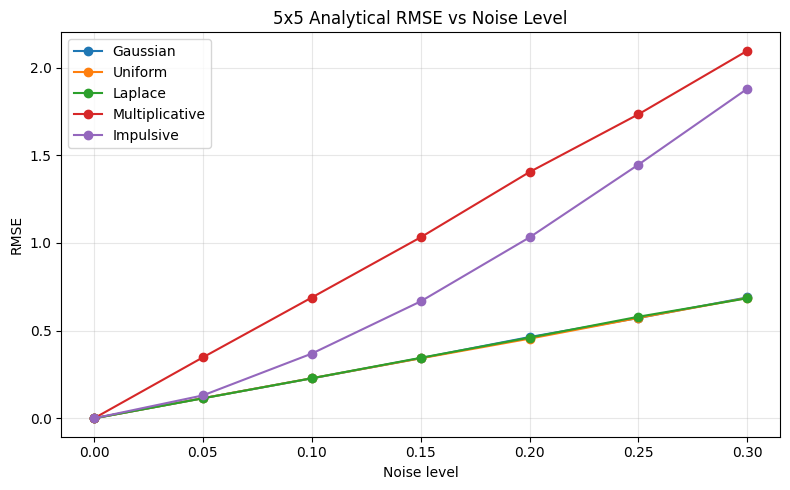

In [58]:
plot_metric_vs_noise(
    analytical_noise_5x5,
    "RMSE",
    "5x5 Analytical RMSE vs Noise Level"
)


## D5. Independent 5×5 Train / Validation / Test Sets

In [59]:
(
    d_train_5x5, m_train_5x5,
    d_val_5x5, m_val_5x5,
    d_test_5x5, m_test_5x5
) = make_independent_datasets(
    K=K_5x5,
    n_cells=25,
    n_train=40000,
    n_val=6000,
    n_test=6000,
    seed=SEED + 5000
)

print("Training:", m_train_5x5.shape)
print("Validation:", m_val_5x5.shape)
print("Testing:", m_test_5x5.shape)


Train / Validation overlap: 0
Train / Test overlap: 0
Validation / Test overlap: 0
Training: (40000, 25)
Validation: (6000, 25)
Testing: (6000, 25)


## D6. 5×5 Pre-processing

In [60]:
x_scaler_5x5 = StandardScaler()
y_scaler_5x5 = StandardScaler()

d_train_5x5_s = x_scaler_5x5.fit_transform(d_train_5x5)
d_val_5x5_s = x_scaler_5x5.transform(d_val_5x5)
d_test_5x5_s = x_scaler_5x5.transform(d_test_5x5)

m_train_5x5_s = y_scaler_5x5.fit_transform(m_train_5x5)
m_val_5x5_s = y_scaler_5x5.transform(m_val_5x5)


## D7. 5×5 MLP Architecture

In [61]:
mlp_5x5 = Sequential([
    Input(
        shape=(K_5x5.shape[0],),
        name="Travel_Time_Input"
    ),

    Dense(
        256,
        activation="relu",
        name="Hidden_Layer_1"
    ),

    Dense(
        192,
        activation="relu",
        name="Hidden_Layer_2"
    ),

    Dense(
        128,
        activation="relu",
        name="Hidden_Layer_3"
    ),

    Dense(
        64,
        activation="relu",
        name="Hidden_Layer_4"
    ),

    Dense(
        25,
        activation="linear",
        name="Slowness_Output_25_Cells"
    )
])

mlp_5x5.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 256)            │        38,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 192)            │        49,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_3 (Dense)          │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_4 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Slowness_Output_25_Cells        │ (None, 25)             │         1,625 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,585 (478.85 KB)

 Trainable params: 122,585 (478.85 KB)

 Non-trainable params: 0 (0.00 B)

## D8. Compile the 5×5 MLP

In [62]:
mlp_5x5.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss="mse",
    metrics=["mae"]
)


## D9. Train the 5×5 MLP

In [63]:
early_stop_5x5 = EarlyStopping(
    monitor="val_loss",
    patience=25,
    restore_best_weights=True
)

start = time.perf_counter()

history_5x5 = mlp_5x5.fit(
    d_train_5x5_s,
    m_train_5x5_s,
    validation_data=(
        d_val_5x5_s,
        m_val_5x5_s
    ),
    epochs=450,
    batch_size=128,
    callbacks=[early_stop_5x5],
    verbose=1
)

training_time_5x5 = time.perf_counter() - start

print("5x5 training time:", training_time_5x5)
print("Epochs actually run:", len(history_5x5.history["loss"]))
print("Best validation loss:", np.min(history_5x5.history["val_loss"]))


Epoch 1/450
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.1147 - mae: 0.2031 - val_loss: 0.0095 - val_mae: 0.0776
Epoch 2/450
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0073 - mae: 0.0675 - val_loss: 0.0065 - val_mae: 0.0642
Epoch 3/450
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0046 - mae: 0.0536 - val_loss: 0.0030 - val_mae: 0.0437
Epoch 4/450
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0030 - mae: 0.0432 - val_loss: 0.0023 - val_mae: 0.0384
Epoch 5/450
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0022 - mae: 0.0365 - val_loss: 0.0015 - val_mae: 0.0309
Epoch 6/450
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0016 - mae: 0.0313 - val_loss: 0.0013 - val_mae: 0.0283
Epoch 7/450
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0013 - mae: 0.0276 - val_loss: 9.2865e-04 - val_mae: 0.0242
Epoch 8/450
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0013 - mae: 0.0265 - val_loss: 0.0025 - val_mae: 0.0386
Epoch 9/450
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s

## D10. Plot 5×5 Training and Validation Loss

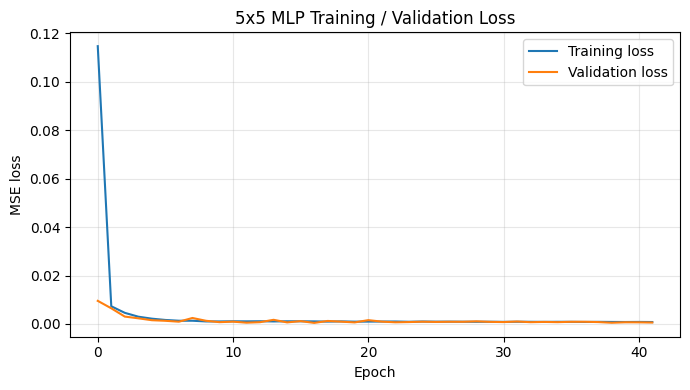

In [64]:
plt.figure(figsize=(7,4))

plt.plot(
    history_5x5.history["loss"],
    label="Training loss"
)

plt.plot(
    history_5x5.history["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("5x5 MLP Training / Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## D11. Clean 5×5 Analytical vs MLP Test Results

In [65]:
start = time.perf_counter()

m_test_analytic_5x5 = analytical_reconstruction_batch(
    K_5x5,
    d_test_5x5
)

analytic_time_5x5 = time.perf_counter() - start

start = time.perf_counter()

m_test_mlp_5x5_s = mlp_5x5.predict(
    d_test_5x5_s,
    verbose=0
)

mlp_time_5x5 = time.perf_counter() - start

m_test_mlp_5x5 = y_scaler_5x5.inverse_transform(
    m_test_mlp_5x5_s
)

clean_5x5 = pd.DataFrame([
    {
        "Grid":"5x5",
        "Method":"Analytical",
        **reconstruction_metrics(
            m_test_5x5,
            m_test_analytic_5x5
        ),
        "Mean Prediction Time (s)":
            analytic_time_5x5 / len(m_test_5x5),
        "Training Time (s)":0.0
    },
    {
        "Grid":"5x5",
        "Method":"MLP",
        **reconstruction_metrics(
            m_test_5x5,
            m_test_mlp_5x5
        ),
        "Mean Prediction Time (s)":
            mlp_time_5x5 / len(m_test_5x5),
        "Training Time (s)":
            training_time_5x5
    }
])

display(clean_5x5)


,Grid,Method,MSE,RMSE,Relative Error (%),Accuracy (%),Mean Prediction Time (s),Training Time (s)
0,5x5,Analytical,3.145487e-14,1.773552e-07,0.000003,99.999997,0.000002,0.000000
1,5x5,MLP,3.372773e-03,5.807558e-02,0.953468,99.046532,0.000087,94.393359


## D12. 5×5 All Five Noise Types - Analytical and MLP

In [66]:
# This code snippet was generated with assistance from ChatGPT.

noise_rows_5x5 = []

M_noise_true_5x5 = m_test_5x5[:1000].astype(float)

D_noise_clean_5x5 = forward_model_batch(
    K_5x5,
    M_noise_true_5x5
)

for noise_index, noise_type in enumerate(NOISE_TYPES):
    for level_index, level in enumerate(NOISE_LEVELS):

        rng = np.random.default_rng(
            SEED + 510000
            + noise_index*10000
            + level_index*100
        )

        D_noisy = add_noise_batch(
            D_noise_clean_5x5,
            noise_type,
            float(level),
            rng
        )

        # Analytical
        start = time.perf_counter()

        M_a = analytical_reconstruction_batch(
            K_5x5,
            D_noisy
        )

        elapsed_a = time.perf_counter() - start

        noise_rows_5x5.append({
            "Grid":"5x5",
            "Method":"Analytical",
            "Noise Type":noise_type,
            "Noise Level":float(level),
            "Simulations":1000,
            **reconstruction_metrics(
                M_noise_true_5x5,
                M_a
            ),
            "Mean Prediction Time (s)":
                elapsed_a / 1000
        })

        # MLP
        D_noisy_s = x_scaler_5x5.transform(
            D_noisy
        )

        start = time.perf_counter()

        M_nn_s = mlp_5x5.predict(
            D_noisy_s,
            verbose=0
        )

        elapsed_nn = time.perf_counter() - start

        M_nn = y_scaler_5x5.inverse_transform(
            M_nn_s
        )

        noise_rows_5x5.append({
            "Grid":"5x5",
            "Method":"MLP",
            "Noise Type":noise_type,
            "Noise Level":float(level),
            "Simulations":1000,
            **reconstruction_metrics(
                M_noise_true_5x5,
                M_nn
            ),
            "Mean Prediction Time (s)":
                elapsed_nn / 1000
        })

noise_5x5 = pd.DataFrame(noise_rows_5x5)

display(noise_5x5)


,Grid,Method,Noise Type,Noise Level,Simulations,MSE,RMSE,Relative Error (%),Accuracy (%),Mean Prediction Time (s)
0,5x5,Analytical,Gaussian,0.00,1000,8.161605e-29,9.034160e-15,1.495937e-13,100.000000,0.000001
1,5x5,MLP,Gaussian,0.00,1000,3.432550e-03,5.858797e-02,9.599464e-01,99.040054,0.000176
2,5x5,Analytical,Gaussian,0.05,1000,1.295496e-02,1.138199e-01,1.896148e+00,98.103852,0.000001
3,5x5,MLP,Gaussian,0.05,1000,3.555879e-02,1.885704e-01,3.149322e+00,96.850678,0.000159
4,5x5,Analytical,Gaussian,0.10,1000,5.193332e-02,2.278888e-01,3.797755e+00,96.202245,0.000001
...,...,...,...,...,...,...,...,...,...,...
65,5x5,MLP,Impulsive,0.20,1000,2.388077e+00,1.545340e+00,2.535833e+01,74.641673,0.000155
66,5x5,Analytical,Impulsive,0.25,1000,2.058435e+00,1.434725e+00,2.368234e+01,76.317659,0.000001
67,5x5,MLP,Impulsive,0.25,1000,4.635563e+00,2.153036e+00,3.556399e+01,64.436009,0.000155
68,5x5,Analytical,Impulsive,0.30,1000,3.441740e+00,1.855193e+00,3.074615e+01,69.253853,0.000001


## D13. 5×5 MLP Input / Output Structure

In [67]:
input_labels_5x5 = [
    f"T{i+1}" for i in range(K_5x5.shape[0])
]

output_labels_5x5 = [
    f"S{i+1}" for i in range(25)
]

print(
    f"Mapping: T1...T{K_5x5.shape[0]} "
    "→ MLP → S1...S25"
)


Mapping: T1...T150 → MLP → S1...S25


## D14. Weird Cases 5×5 Slowness

In [68]:
base_5 = np.full((5,5), 2.0)

case_5_equal = np.full((5,5), 5.0)

case_5_one_peak = base_5.copy()
case_5_one_peak[2,2] = 8.0

case_5_two_peaks = base_5.copy()
case_5_two_peaks[0,4] = 7.5
case_5_two_peaks[4,0] = 7.8

case_5_high_contrast = np.indices((5,5)).sum(axis=0) % 2
case_5_high_contrast = np.where(
    case_5_high_contrast == 0,
    0.8,
    9.2
)

challenging_cases_5x5 = {
    "Nearly equal cells":case_5_equal.ravel(),
    "One central high peak":case_5_one_peak.ravel(),
    "Two separated peaks":case_5_two_peaks.ravel(),
    "High contrast":case_5_high_contrast.ravel()
}

rows_5x5 = []

for case_name, true_m in challenging_cases_5x5.items():

    d_case = forward_model(K_5x5, true_m)
    a_hat = analytical_reconstruction(K_5x5, d_case)

    d_case_s = x_scaler_5x5.transform(
        d_case.reshape(1,-1)
    )

    n_hat_s = mlp_5x5.predict(
        d_case_s,
        verbose=0
    )

    n_hat = y_scaler_5x5.inverse_transform(
        n_hat_s
    )[0]

    rows_5x5.extend([
        {
            "Case":case_name,
            "Method":"Analytical",
            **reconstruction_metrics(true_m, a_hat)
        },
        {
            "Case":case_name,
            "Method":"MLP",
            **reconstruction_metrics(true_m, n_hat)
        }
    ])

weird_cases_5x5 = pd.DataFrame(rows_5x5)
display(weird_cases_5x5)


,Case,Method,MSE,RMSE,Relative Error (%),Accuracy (%)
0,Nearly equal cells,Analytical,2.126769e-29,4.611691e-15,9.223381e-14,100.000000
1,Nearly equal cells,MLP,9.715250e-05,9.856597e-03,1.971319e-01,99.802868
2,One central high peak,Analytical,7.257520e-30,2.693979e-15,1.064889e-13,100.000000
3,One central high peak,MLP,1.304751e-02,1.142257e-01,4.515167e+00,95.484833
4,Two separated peaks,Analytical,6.882811e-30,2.623511e-15,9.071650e-14,100.000000
5,Two separated peaks,MLP,8.508483e-03,9.224144e-02,3.189550e+00,96.810450
6,High contrast,Analytical,5.549045e-29,7.449191e-15,1.163936e-13,100.000000
7,High contrast,MLP,1.025180e-02,1.012512e-01,1.582049e+00,98.417951


## D15. 5×5 Peak Detectability vs Noise Level

In [69]:
# Generated with ChatGPT assistance and adapted for this project.

peak_grid_5x5 = np.full((5,5), 2.0)
peak_grid_5x5[2,2] = 8.0

peak_model_5x5 = peak_grid_5x5.ravel()
true_peak_cell_5x5 = int(np.argmax(peak_model_5x5))

peak_rows_5x5 = []

for noise_type in NOISE_TYPES:
    for level_index, level in enumerate(NOISE_LEVELS):

        D_clean = np.repeat(
            forward_model(K_5x5, peak_model_5x5).reshape(1,-1),
            N_MONTE_CARLO,
            axis=0
        )

        rng = np.random.default_rng(
            SEED + 550000
            + 10000*NOISE_TYPES.index(noise_type)
            + 100*level_index
        )

        D_noisy = add_noise_batch(
            D_clean, noise_type, float(level), rng
        )

        A_hat = analytical_reconstruction_batch(
            K_5x5, D_noisy
        )

        a_detect = np.mean(
            np.argmax(A_hat, axis=1) == true_peak_cell_5x5
        ) * 100.0

        D_noisy_s = x_scaler_5x5.transform(D_noisy)
        N_hat_s = mlp_5x5.predict(D_noisy_s, verbose=0)
        N_hat = y_scaler_5x5.inverse_transform(N_hat_s)

        n_detect = np.mean(
            np.argmax(N_hat, axis=1) == true_peak_cell_5x5
        ) * 100.0

        peak_rows_5x5.extend([
            {
                "Grid":"5x5",
                "Noise Type":noise_type,
                "Noise Level":float(level),
                "Method":"Analytical",
                "Peak Detected (%)":a_detect
            },
            {
                "Grid":"5x5",
                "Noise Type":noise_type,
                "Noise Level":float(level),
                "Method":"MLP",
                "Peak Detected (%)":n_detect
            }
        ])

peak_detection_5x5 = pd.DataFrame(peak_rows_5x5)
display(peak_detection_5x5)


,Grid,Noise Type,Noise Level,Method,Peak Detected (%)
0,5x5,Gaussian,0.00,Analytical,100.0
1,5x5,Gaussian,0.00,MLP,100.0
2,5x5,Gaussian,0.05,Analytical,100.0
3,5x5,Gaussian,0.05,MLP,100.0
4,5x5,Gaussian,0.10,Analytical,100.0
...,...,...,...,...,...
65,5x5,Impulsive,0.20,MLP,100.0
66,5x5,Impulsive,0.25,Analytical,100.0
67,5x5,Impulsive,0.25,MLP,99.7
68,5x5,Impulsive,0.30,Analytical,99.9


# PART E - 6×6 TOY MODEL

## E1. The 6×6 Model

In [70]:
K_6x6, rays_6x6 = build_problem(6)

print("6x6 K shape:", K_6x6.shape)
print("Rank:", np.linalg.matrix_rank(K_6x6))
print("Condition number:", np.linalg.cond(K_6x6))
print("Equations:", K_6x6.shape[0])
print("Unknown slowness parameters:", K_6x6.shape[1])


6x6 K shape: (216, 36)
Rank: 36
Condition number: 4.854494738650921
Equations: 216
Unknown slowness parameters: 36


## E2. 6×6 Analytical Reconstruction Without Noise

In [71]:
rng = np.random.default_rng(SEED + 6001)

m_true_6x6 = rng.uniform(
    SLOWNESS_MIN,
    SLOWNESS_MAX,
    size=36
)

d_clean_6x6 = forward_model(
    K_6x6,
    m_true_6x6
)

m_hat_6x6 = analytical_reconstruction(
    K_6x6,
    d_clean_6x6
)

print("True slowness shape:", m_true_6x6.shape)
print("Analytical reconstruction shape:", m_hat_6x6.shape)
print(
    reconstruction_metrics(
        m_true_6x6,
        m_hat_6x6
    )
)


True slowness shape: (36,)
Analytical reconstruction shape: (36,)
{'MSE': 2.113024194842518e-28, 'RMSE': 1.4536245026974876e-14, 'Relative Error (%)': np.float64(2.464929988443919e-13), 'Accuracy (%)': np.float64(99.99999999999976)}


## E3. 6×6 Analytical Error vs Noise - 1,000 Simulations

In [72]:
analytical_noise_6x6 = analytical_monte_carlo(
    n=6,
    K=K_6x6,
    n_simulations=1000
)

display(analytical_noise_6x6)


,Grid,Noise Type,Noise Level,Simulations,MSE,RMSE,Relative Error (%),Accuracy (%),Mean Reconstruction Time (s)
0,6x6,Gaussian,0.00,1000,8.093707e-29,8.996503e-15,1.508097e-13,100.000000,0.000005
1,6x6,Gaussian,0.05,1000,1.506151e-02,1.227253e-01,2.041935e+00,97.958065,0.000002
2,6x6,Gaussian,0.10,1000,5.992692e-02,2.447998e-01,4.098225e+00,95.901775,0.000002
3,6x6,Gaussian,0.15,1000,1.341784e-01,3.663038e-01,6.106629e+00,93.893371,0.000002
4,6x6,Gaussian,0.20,1000,2.465957e-01,4.965840e-01,8.279398e+00,91.720602,0.000002
5,6x6,Gaussian,0.25,1000,3.784337e-01,6.151696e-01,1.028389e+01,89.716112,0.000002
6,6x6,Gaussian,0.30,1000,5.413491e-01,7.357643e-01,1.227673e+01,87.723273,0.000002
7,6x6,Uniform,0.00,1000,8.202919e-29,9.056997e-15,1.523788e-13,100.000000,0.000002
8,6x6,Uniform,0.05,1000,1.480181e-02,1.216627e-01,2.037932e+00,97.962068,0.000002
9,6x6,Uniform,0.10,1000,6.015261e-02,2.452603e-01,4.097717e+00,95.902283,0.000002


## E4. Plot 6×6 Analytical RMSE vs Noise Level

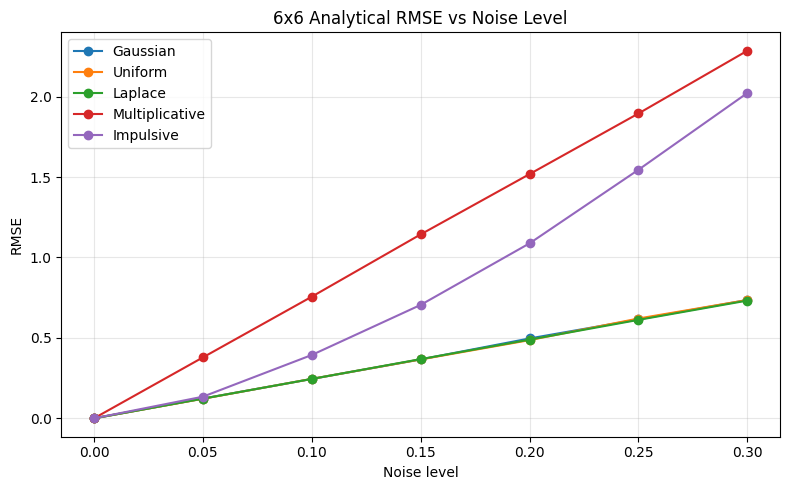

In [73]:
plot_metric_vs_noise(
    analytical_noise_6x6,
    "RMSE",
    "6x6 Analytical RMSE vs Noise Level"
)


## E5. Independent 6×6 Train / Validation / Test Sets

In [74]:
(
    d_train_6x6, m_train_6x6,
    d_val_6x6, m_val_6x6,
    d_test_6x6, m_test_6x6
) = make_independent_datasets(
    K=K_6x6,
    n_cells=36,
    n_train=50000,
    n_val=7000,
    n_test=7000,
    seed=SEED + 6000
)

print("Training:", m_train_6x6.shape)
print("Validation:", m_val_6x6.shape)
print("Testing:", m_test_6x6.shape)


Train / Validation overlap: 0
Train / Test overlap: 0
Validation / Test overlap: 0
Training: (50000, 36)
Validation: (7000, 36)
Testing: (7000, 36)


## E6. 6×6 Pre-processing

In [75]:
x_scaler_6x6 = StandardScaler()
y_scaler_6x6 = StandardScaler()

d_train_6x6_s = x_scaler_6x6.fit_transform(d_train_6x6)
d_val_6x6_s = x_scaler_6x6.transform(d_val_6x6)
d_test_6x6_s = x_scaler_6x6.transform(d_test_6x6)

m_train_6x6_s = y_scaler_6x6.fit_transform(m_train_6x6)
m_val_6x6_s = y_scaler_6x6.transform(m_val_6x6)


## E7. 6×6 MLP Architecture

In [76]:
mlp_6x6 = Sequential([
    Input(
        shape=(K_6x6.shape[0],),
        name="Travel_Time_Input"
    ),

    Dense(
        320,
        activation="relu",
        name="Hidden_Layer_1"
    ),

    Dense(
        256,
        activation="relu",
        name="Hidden_Layer_2"
    ),

    Dense(
        192,
        activation="relu",
        name="Hidden_Layer_3"
    ),

    Dense(
        128,
        activation="relu",
        name="Hidden_Layer_4"
    ),

    Dense(
        64,
        activation="relu",
        name="Hidden_Layer_5"
    ),

    Dense(
        36,
        activation="linear",
        name="Slowness_Output_36_Cells"
    )
])

mlp_6x6.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 320)            │        69,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 256)            │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_3 (Dense)          │ (None, 192)            │        49,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_4 (Dense)          │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_5 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Slowness_Output_36_Cells        │ (None, 36)             │         2,340 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 236,260 (922.89 KB)

 Trainable params: 236,260 (922.89 KB)

 Non-trainable params: 0 (0.00 B)

## E8. Compile the 6×6 MLP

In [77]:
mlp_6x6.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss="mse",
    metrics=["mae"]
)


## E9. Train the 6×6 MLP

In [ ]:
early_stop_6x6 = EarlyStopping(
    monitor="val_loss",
    patience=25,
    restore_best_weights=True
)

start = time.perf_counter()

history_6x6 = mlp_6x6.fit(
    d_train_6x6_s,
    m_train_6x6_s,
    validation_data=(
        d_val_6x6_s,
        m_val_6x6_s
    ),
    epochs=500,
    batch_size=128,
    callbacks=[early_stop_6x6],
    verbose=1
)

training_time_6x6 = time.perf_counter() - start

print("6x6 training time:", training_time_6x6)
print("Epochs actually run:", len(history_6x6.history["loss"]))
print("Best validation loss:", np.min(history_6x6.history["val_loss"]))


## E10. Plot 6×6 Training and Validation Loss

In [ ]:
plt.figure(figsize=(7,4))

plt.plot(
    history_6x6.history["loss"],
    label="Training loss"
)

plt.plot(
    history_6x6.history["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("6x6 MLP Training / Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## E11. Clean 6×6 Analytical vs MLP Test Results

In [ ]:
start = time.perf_counter()

m_test_analytic_6x6 = analytical_reconstruction_batch(
    K_6x6,
    d_test_6x6
)

analytic_time_6x6 = time.perf_counter() - start

start = time.perf_counter()

m_test_mlp_6x6_s = mlp_6x6.predict(
    d_test_6x6_s,
    verbose=0
)

mlp_time_6x6 = time.perf_counter() - start

m_test_mlp_6x6 = y_scaler_6x6.inverse_transform(
    m_test_mlp_6x6_s
)

clean_6x6 = pd.DataFrame([
    {
        "Grid":"6x6",
        "Method":"Analytical",
        **reconstruction_metrics(
            m_test_6x6,
            m_test_analytic_6x6
        ),
        "Mean Prediction Time (s)":
            analytic_time_6x6 / len(m_test_6x6),
        "Training Time (s)":0.0
    },
    {
        "Grid":"6x6",
        "Method":"MLP",
        **reconstruction_metrics(
            m_test_6x6,
            m_test_mlp_6x6
        ),
        "Mean Prediction Time (s)":
            mlp_time_6x6 / len(m_test_6x6),
        "Training Time (s)":
            training_time_6x6
    }
])

display(clean_6x6)


## E12. 6×6 All Five Noise Types - Analytical and MLP

In [ ]:
# This code snippet was generated with assistance from ChatGPT.

noise_rows_6x6 = []

M_noise_true_6x6 = m_test_6x6[:1000].astype(float)

D_noise_clean_6x6 = forward_model_batch(
    K_6x6,
    M_noise_true_6x6
)

for noise_index, noise_type in enumerate(NOISE_TYPES):
    for level_index, level in enumerate(NOISE_LEVELS):

        rng = np.random.default_rng(
            SEED + 610000
            + noise_index*10000
            + level_index*100
        )

        D_noisy = add_noise_batch(
            D_noise_clean_6x6,
            noise_type,
            float(level),
            rng
        )

        # Analytical
        start = time.perf_counter()

        M_a = analytical_reconstruction_batch(
            K_6x6,
            D_noisy
        )

        elapsed_a = time.perf_counter() - start

        noise_rows_6x6.append({
            "Grid":"6x6",
            "Method":"Analytical",
            "Noise Type":noise_type,
            "Noise Level":float(level),
            "Simulations":1000,
            **reconstruction_metrics(
                M_noise_true_6x6,
                M_a
            ),
            "Mean Prediction Time (s)":
                elapsed_a / 1000
        })

        # MLP
        D_noisy_s = x_scaler_6x6.transform(
            D_noisy
        )

        start = time.perf_counter()

        M_nn_s = mlp_6x6.predict(
            D_noisy_s,
            verbose=0
        )

        elapsed_nn = time.perf_counter() - start

        M_nn = y_scaler_6x6.inverse_transform(
            M_nn_s
        )

        noise_rows_6x6.append({
            "Grid":"6x6",
            "Method":"MLP",
            "Noise Type":noise_type,
            "Noise Level":float(level),
            "Simulations":1000,
            **reconstruction_metrics(
                M_noise_true_6x6,
                M_nn
            ),
            "Mean Prediction Time (s)":
                elapsed_nn / 1000
        })

noise_6x6 = pd.DataFrame(noise_rows_6x6)

display(noise_6x6)


## E13. 6×6 MLP Input / Output Structure

In [ ]:
input_labels_6x6 = [
    f"T{i+1}" for i in range(K_6x6.shape[0])
]

output_labels_6x6 = [
    f"S{i+1}" for i in range(36)
]

print(
    f"Mapping: T1...T{K_6x6.shape[0]} "
    "→ MLP → S1...S36"
)


## E14. Weird Cases 6×6 Slowness

In [ ]:
base_6 = np.full((6,6), 2.0)

case_6_equal = np.full((6,6), 5.0)

case_6_one_peak = base_6.copy()
case_6_one_peak[2,3] = 8.0

case_6_two_peaks = base_6.copy()
case_6_two_peaks[0,5] = 7.5
case_6_two_peaks[5,0] = 7.8

case_6_high_contrast = np.indices((6,6)).sum(axis=0) % 2
case_6_high_contrast = np.where(
    case_6_high_contrast == 0,
    0.8,
    9.2
)

challenging_cases_6x6 = {
    "Nearly equal cells":case_6_equal.ravel(),
    "One high peak":case_6_one_peak.ravel(),
    "Two separated peaks":case_6_two_peaks.ravel(),
    "High contrast":case_6_high_contrast.ravel()
}

rows_6x6 = []

for case_name, true_m in challenging_cases_6x6.items():

    d_case = forward_model(K_6x6, true_m)
    a_hat = analytical_reconstruction(K_6x6, d_case)

    d_case_s = x_scaler_6x6.transform(
        d_case.reshape(1,-1)
    )

    n_hat_s = mlp_6x6.predict(
        d_case_s,
        verbose=0
    )

    n_hat = y_scaler_6x6.inverse_transform(
        n_hat_s
    )[0]

    rows_6x6.extend([
        {
            "Case":case_name,
            "Method":"Analytical",
            **reconstruction_metrics(true_m, a_hat)
        },
        {
            "Case":case_name,
            "Method":"MLP",
            **reconstruction_metrics(true_m, n_hat)
        }
    ])

weird_cases_6x6 = pd.DataFrame(rows_6x6)
display(weird_cases_6x6)


## E15. 6×6 Peak Detectability vs Noise Level

In [ ]:
# Generated with ChatGPT assistance and adapted for this project.

peak_grid_6x6 = np.full((6,6), 2.0)
peak_grid_6x6[2,3] = 8.0

peak_model_6x6 = peak_grid_6x6.ravel()
true_peak_cell_6x6 = int(np.argmax(peak_model_6x6))

peak_rows_6x6 = []

for noise_type in NOISE_TYPES:
    for level_index, level in enumerate(NOISE_LEVELS):

        D_clean = np.repeat(
            forward_model(K_6x6, peak_model_6x6).reshape(1,-1),
            N_MONTE_CARLO,
            axis=0
        )

        rng = np.random.default_rng(
            SEED + 560000
            + 10000*NOISE_TYPES.index(noise_type)
            + 100*level_index
        )

        D_noisy = add_noise_batch(
            D_clean, noise_type, float(level), rng
        )

        A_hat = analytical_reconstruction_batch(
            K_6x6, D_noisy
        )

        a_detect = np.mean(
            np.argmax(A_hat, axis=1) == true_peak_cell_6x6
        ) * 100.0

        D_noisy_s = x_scaler_6x6.transform(D_noisy)
        N_hat_s = mlp_6x6.predict(D_noisy_s, verbose=0)
        N_hat = y_scaler_6x6.inverse_transform(N_hat_s)

        n_detect = np.mean(
            np.argmax(N_hat, axis=1) == true_peak_cell_6x6
        ) * 100.0

        peak_rows_6x6.extend([
            {
                "Grid":"6x6",
                "Noise Type":noise_type,
                "Noise Level":float(level),
                "Method":"Analytical",
                "Peak Detected (%)":a_detect
            },
            {
                "Grid":"6x6",
                "Noise Type":noise_type,
                "Noise Level":float(level),
                "Method":"MLP",
                "Peak Detected (%)":n_detect
            }
        ])

peak_detection_6x6 = pd.DataFrame(peak_rows_6x6)
display(peak_detection_6x6)


# PART F - COMPARE 2×2, 3×3, 4×4, 5×5 AND 6×6

## F1. Clean Analytical vs MLP Comparison - All Grid Sizes

In [ ]:
all_clean = pd.concat([
    clean_2x2,
    clean_3x3,
    clean_4x4,
    clean_5x5,
    clean_6x6
], ignore_index=True)

display(all_clean)


## F2. Clean Accuracy Comparison Plot - All Grid Sizes

In [ ]:
plt.figure(figsize=(9,5))

for method in ["Analytical","MLP"]:

    sub = all_clean[
        all_clean["Method"] == method
    ]

    plt.plot(
        sub["Grid"],
        sub["Accuracy (%)"],
        marker="o",
        label=method
    )

plt.ylabel("Accuracy (%)")
plt.title(
    "Clean Accuracy Comparison: "
    "2x2 to 6x6"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## F3. Clean RMSE Comparison Plot - All Grid Sizes

In [ ]:
plt.figure(figsize=(9,5))

for method in ["Analytical","MLP"]:

    sub = all_clean[
        all_clean["Method"] == method
    ]

    plt.plot(
        sub["Grid"],
        sub["RMSE"],
        marker="o",
        label=method
    )

plt.yscale("log")
plt.ylabel("RMSE (log scale)")
plt.title("Clean RMSE Comparison: 2x2 to 6x6")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## F4. Clean Prediction-Time Comparison - All Grid Sizes

In [ ]:
plt.figure(figsize=(9,5))

for method in ["Analytical","MLP"]:

    sub = all_clean[
        all_clean["Method"] == method
    ]

    plt.plot(
        sub["Grid"],
        sub["Mean Prediction Time (s)"],
        marker="o",
        label=method
    )

plt.yscale("log")
plt.ylabel("Mean prediction time (s, log scale)")
plt.title("Prediction Time Comparison: 2x2 to 6x6")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## F5. Combine All Five Noise Results

In [ ]:
all_noise = pd.concat([
    noise_2x2,
    noise_3x3,
    noise_4x4,
    noise_5x5,
    noise_6x6
], ignore_index=True)

display(all_noise)


## F6. Gaussian Noise Comparison — 2×2 to 6×6

In [ ]:
gaussian = all_noise[
    all_noise["Noise Type"] == "Gaussian"
]

display(gaussian)

plt.figure(figsize=(10,6))

for grid in ["2x2","3x3","4x4","5x5","6x6"]:
    for method in ["Analytical","MLP"]:

        sub = gaussian[
            (gaussian["Grid"] == grid)
            &
            (gaussian["Method"] == method)
        ]

        plt.plot(
            sub["Noise Level"],
            sub["RMSE"],
            marker="o",
            label=f"{grid} {method}"
        )

plt.xlabel("Gaussian noise level")
plt.ylabel("RMSE")
plt.title("Gaussian Noise Comparison: 2x2 to 6x6")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## F7. Uniform Noise Comparison - 2×2 to 6×6

In [ ]:
uniform = all_noise[
    all_noise["Noise Type"] == "Uniform"
]

display(uniform)

plt.figure(figsize=(10,6))

for grid in ["2x2","3x3","4x4","5x5","6x6"]:
    for method in ["Analytical","MLP"]:

        sub = uniform[
            (uniform["Grid"] == grid)
            &
            (uniform["Method"] == method)
        ]

        plt.plot(
            sub["Noise Level"],
            sub["RMSE"],
            marker="o",
            label=f"{grid} {method}"
        )

plt.xlabel("Uniform noise level")
plt.ylabel("RMSE")
plt.title("Uniform Noise Comparison: 2x2 to 6x6")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## F8. Laplace Noise Comparison - 2×2 to 6×6

In [ ]:
laplace = all_noise[
    all_noise["Noise Type"] == "Laplace"
]

display(laplace)

plt.figure(figsize=(10,6))

for grid in ["2x2","3x3","4x4","5x5","6x6"]:
    for method in ["Analytical","MLP"]:

        sub = laplace[
            (laplace["Grid"] == grid)
            &
            (laplace["Method"] == method)
        ]

        plt.plot(
            sub["Noise Level"],
            sub["RMSE"],
            marker="o",
            label=f"{grid} {method}"
        )

plt.xlabel("Laplace noise level")
plt.ylabel("RMSE")
plt.title("Laplace Noise Comparison: 2x2 to 6x6")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## F9. Multiplicative Noise Comparison - 2×2 to 6×6

In [ ]:
multiplicative = all_noise[
    all_noise["Noise Type"] == "Multiplicative"
]

display(multiplicative)

plt.figure(figsize=(10,6))

for grid in ["2x2","3x3","4x4","5x5","6x6"]:
    for method in ["Analytical","MLP"]:

        sub = multiplicative[
            (multiplicative["Grid"] == grid)
            &
            (multiplicative["Method"] == method)
        ]

        plt.plot(
            sub["Noise Level"],
            sub["RMSE"],
            marker="o",
            label=f"{grid} {method}"
        )

plt.xlabel("Multiplicative noise level")
plt.ylabel("RMSE")
plt.title("Multiplicative Noise Comparison: 2x2 to 6x6")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## F10. Impulsive Noise Comparison - 2×2 to 6×6

In [ ]:
impulsive = all_noise[
    all_noise["Noise Type"] == "Impulsive"
]

display(impulsive)

plt.figure(figsize=(10,6))

for grid in ["2x2","3x3","4x4","5x5","6x6"]:
    for method in ["Analytical","MLP"]:

        sub = impulsive[
            (impulsive["Grid"] == grid)
            &
            (impulsive["Method"] == method)
        ]

        plt.plot(
            sub["Noise Level"],
            sub["RMSE"],
            marker="o",
            label=f"{grid} {method}"
        )

plt.xlabel("Impulsive noise level")
plt.ylabel("RMSE")
plt.title("Impulsive Noise Comparison: 2x2 to 6x6")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## F11. Final Summary Table - All Models and All Noise Types

In [ ]:
final_summary = (
    all_noise
    .groupby(
        ["Grid","Method","Noise Type"],
        as_index=False
    )
    .agg({
        "RMSE":"mean",
        "Relative Error (%)":"mean",
        "Accuracy (%)":"mean",
        "Mean Prediction Time (s)":"mean"
    })
)

display(final_summary)


## F12. Compare Weird Cases Across All Grid Sizes

In [ ]:
all_weird_cases = pd.concat([
    weird_cases_2x2.assign(Grid="2x2"),
    weird_cases_3x3.assign(Grid="3x3"),
    weird_cases_4x4.assign(Grid="4x4"),
    weird_cases_5x5.assign(Grid="5x5"),
    weird_cases_6x6.assign(Grid="6x6")
], ignore_index=True)

display(all_weird_cases)


## F14. Compare Peak Detectability Across All Grid Sizes

In [ ]:
all_peak_detection = pd.concat([
    peak_detection_2x2.assign(Grid="2x2"),
    peak_detection_3x3,
    peak_detection_4x4,
    peak_detection_5x5,
    peak_detection_6x6
], ignore_index=True)

display(all_peak_detection)


## F15. Peak Detectability Comparison Plot - All Grid Sizes

In [ ]:
for noise_type in NOISE_TYPES:

    plt.figure(figsize=(10,6))

    for grid in ["2x2","3x3","4x4","5x5","6x6"]:
        for method in ["Analytical","MLP"]:

            sub = all_peak_detection[
                (all_peak_detection["Noise Type"] == noise_type)
                &
                (all_peak_detection["Grid"] == grid)
                &
                (all_peak_detection["Method"] == method)
            ]

            plt.plot(
                sub["Noise Level"],
                sub["Peak Detected (%)"],
                marker="o",
                label=f"{grid} {method}"
            )

    plt.xlabel("Noise level")
    plt.ylabel("Correct peak detection (%)")
    plt.ylim(0,105)
    plt.title(
        f"Peak Detectability Comparison — {noise_type}"
    )
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# PART G — ADDITIONAL CHECKS


## G1. Ray and Sensitivity-Matrix Summary


In [ ]:
matrix_summary_rows = []

grid_items = [
    ("2x2", K_2x2, None),
    ("3x3", K_3x3, rays_3x3),
    ("4x4", K_4x4, rays_4x4),
    ("5x5", K_5x5, rays_5x5),
    ("6x6", K_6x6, rays_6x6)
]

for grid_name, K, rays in grid_items:
    if rays is None:
        horizontal = 0
        vertical = 0
        diagonal = 0
        ray_note = "Manual four-measurement design"
    else:
        horizontal = sum(r["type"] == "Horizontal" for r in rays)
        vertical = sum(r["type"] == "Vertical" for r in rays)
        diagonal = sum(r["type"] == "Diagonal" for r in rays)
        ray_note = "Boundary-point ray geometry"

    matrix_summary_rows.append({
        "Grid": grid_name,
        "Measurements": K.shape[0],
        "Unknowns": K.shape[1],
        "Rank": np.linalg.matrix_rank(K),
        "Condition number": np.linalg.cond(K),
        "Horizontal rays": horizontal,
        "Vertical rays": vertical,
        "Diagonal rays": diagonal,
        "Geometry": ray_note
    })

matrix_summary = pd.DataFrame(matrix_summary_rows)

display(matrix_summary)

matrix_summary.to_csv(
    OUTPUT_DIR / "FINAL_ray_matrix_summary.csv",
    index=False
)


## G2. 2×2 Measurement Definition Check


In [ ]:
measurement_2x2 = pd.DataFrame({
    "Measurement": ["T1", "T2", "T3", "T4"],
    "Equation": [
        "T1 = S1 + S2",
        "T2 = S3 + S4",
        "T3 = S1 + S3",
        "T4 = S1 + S4"
    ]
})

display(measurement_2x2)

print("2x2 K matrix:")
print(K_2x2)
print("Rank:", np.linalg.matrix_rank(K_2x2))
print("Condition number:", np.linalg.cond(K_2x2))


## G3. Sample-Level Error Summary


In [ ]:
def sample_error_summary(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    sample_rmse = np.sqrt(
        np.mean((y_true - y_pred) ** 2, axis=1)
    )

    sample_relative_error = (
        np.linalg.norm(y_true - y_pred, axis=1)
        / np.maximum(np.linalg.norm(y_true, axis=1), 1e-12)
    ) * 100.0

    return {
        "Mean RMSE": np.mean(sample_rmse),
        "SD RMSE": np.std(sample_rmse, ddof=1),
        "Mean Relative Error (%)": np.mean(sample_relative_error),
        "SD Relative Error (%)": np.std(sample_relative_error, ddof=1)
    }


sample_error_rows = []

test_pairs = [
    ("2x2", m_test_2x2, m_test_mlp_2x2),
    ("3x3", m_test_3x3, m_test_mlp_3x3),
    ("4x4", m_test_4x4, m_test_mlp_4x4),
    ("5x5", m_test_5x5, m_test_mlp_5x5),
    ("6x6", m_test_6x6, m_test_mlp_6x6)
]

for grid_name, y_true, y_pred in test_pairs:
    sample_error_rows.append({
        "Grid": grid_name,
        **sample_error_summary(y_true, y_pred)
    })

sample_error_table = pd.DataFrame(sample_error_rows)

display(sample_error_table)

sample_error_table.to_csv(
    OUTPUT_DIR / "FINAL_sample_level_error_summary.csv",
    index=False
)


## G4. MLP Stability Across Five Random Seeds


In [ ]:
# This code snippet was generated with assistance from ChatGPT.
def build_seed_model(input_size, output_size, hidden_units, seed):
    tf.keras.backend.clear_session()

    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)

    model = Sequential()
    model.add(Input(shape=(input_size,)))

    for units in hidden_units:
        model.add(Dense(units, activation="relu"))

    model.add(Dense(output_size, activation="linear"))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )

    return model


seed_values = [11, 22, 33, 44, 55]

seed_configs = {
    "2x2": {
        "x_train": d_train_2x2_s,
        "y_train": m_train_2x2_s,
        "x_val": d_val_2x2_s,
        "y_val": m_val_2x2_s,
        "x_test": d_test_2x2_s,
        "y_test": m_test_2x2,
        "y_scaler": y_scaler_2x2,
        "hidden": [64, 64],
        "epochs": 300
    },
    "3x3": {
        "x_train": d_train_3x3_s,
        "y_train": m_train_3x3_s,
        "x_val": d_val_3x3_s,
        "y_val": m_val_3x3_s,
        "x_test": d_test_3x3_s,
        "y_test": m_test_3x3,
        "y_scaler": y_scaler_3x3,
        "hidden": [128, 128, 64],
        "epochs": 350
    },
    "4x4": {
        "x_train": d_train_4x4_s,
        "y_train": m_train_4x4_s,
        "x_val": d_val_4x4_s,
        "y_val": m_val_4x4_s,
        "x_test": d_test_4x4_s,
        "y_test": m_test_4x4,
        "y_scaler": y_scaler_4x4,
        "hidden": [192, 128, 64],
        "epochs": 400
    },
    "5x5": {
        "x_train": d_train_5x5_s,
        "y_train": m_train_5x5_s,
        "x_val": d_val_5x5_s,
        "y_val": m_val_5x5_s,
        "x_test": d_test_5x5_s,
        "y_test": m_test_5x5,
        "y_scaler": y_scaler_5x5,
        "hidden": [256, 192, 128, 64],
        "epochs": 450
    },
    "6x6": {
        "x_train": d_train_6x6_s,
        "y_train": m_train_6x6_s,
        "x_val": d_val_6x6_s,
        "y_val": m_val_6x6_s,
        "x_test": d_test_6x6_s,
        "y_test": m_test_6x6,
        "y_scaler": y_scaler_6x6,
        "hidden": [320, 256, 192, 128, 64],
        "epochs": 500
    }
}

seed_rows = []

for grid_name, cfg in seed_configs.items():
    print("\nRunning:", grid_name)

    for seed in seed_values:
        model = build_seed_model(
            input_size=cfg["x_train"].shape[1],
            output_size=cfg["y_train"].shape[1],
            hidden_units=cfg["hidden"],
            seed=seed
        )

        stop = EarlyStopping(
            monitor="val_loss",
            patience=25,
            restore_best_weights=True
        )

        start = time.perf_counter()

        history = model.fit(
            cfg["x_train"],
            cfg["y_train"],
            validation_data=(
                cfg["x_val"],
                cfg["y_val"]
            ),
            epochs=cfg["epochs"],
            batch_size=128,
            callbacks=[stop],
            verbose=0
        )

        train_time = time.perf_counter() - start

        pred_scaled = model.predict(
            cfg["x_test"],
            verbose=0
        )

        pred = cfg["y_scaler"].inverse_transform(
            pred_scaled
        )

        metrics = reconstruction_metrics(
            cfg["y_test"],
            pred
        )

        seed_rows.append({
            "Grid": grid_name,
            "Seed": seed,
            "Epochs": len(history.history["loss"]),
            "Best Validation Loss": np.min(
                history.history["val_loss"]
            ),
            "Training Time (s)": train_time,
            **metrics
        })

        print(
            grid_name,
            "seed", seed,
            "RMSE =", round(metrics["RMSE"], 6),
            "Relative error =", round(
                metrics["Relative Error (%)"], 6
            )
        )

seed_results = pd.DataFrame(seed_rows)

display(seed_results)

seed_results.to_csv(
    OUTPUT_DIR / "FINAL_mlp_seed_runs.csv",
    index=False
)



Running: 2x2
2x2 seed 11 RMSE = 0.007349 Relative error = 0.131978


## G5. MLP Seed Stability Summary


In [ ]:
seed_summary = (
    seed_results
    .groupby("Grid", as_index=False)
    .agg(
        Mean_RMSE=("RMSE", "mean"),
        SD_RMSE=("RMSE", "std"),
        Mean_Relative_Error=(
            "Relative Error (%)", "mean"
        ),
        SD_Relative_Error=(
            "Relative Error (%)", "std"
        ),
        Mean_Accuracy=("Accuracy (%)", "mean"),
        SD_Accuracy=("Accuracy (%)", "std"),
        Mean_Training_Time=(
            "Training Time (s)", "mean"
        )
    )
)

display(seed_summary)

seed_summary.to_csv(
    OUTPUT_DIR / "FINAL_mlp_seed_summary.csv",
    index=False
)


## G6. 4×4 Architecture Check


In [ ]:
# This code snippet was generated with assistance from ChatGPT.
architecture_options = {
    "Small": [128, 64],
    "Current": [192, 128, 64],
    "Larger": [256, 128, 64]
}

architecture_rows = []

for name, hidden_units in architecture_options.items():
    model = build_seed_model(
        input_size=d_train_4x4_s.shape[1],
        output_size=m_train_4x4_s.shape[1],
        hidden_units=hidden_units,
        seed=42
    )

    stop = EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True
    )

    history = model.fit(
        d_train_4x4_s,
        m_train_4x4_s,
        validation_data=(
            d_val_4x4_s,
            m_val_4x4_s
        ),
        epochs=250,
        batch_size=128,
        callbacks=[stop],
        verbose=0
    )

    pred_scaled = model.predict(
        d_test_4x4_s,
        verbose=0
    )

    pred = y_scaler_4x4.inverse_transform(
        pred_scaled
    )

    metrics = reconstruction_metrics(
        m_test_4x4,
        pred
    )

    architecture_rows.append({
        "Architecture": name,
        "Hidden layers": str(hidden_units),
        "Best validation loss":
            np.min(history.history["val_loss"]),
        "Epochs": len(history.history["loss"]),
        **metrics
    })

architecture_check = pd.DataFrame(architecture_rows)

display(architecture_check)

architecture_check.to_csv(
    OUTPUT_DIR / "FINAL_4x4_architecture_check.csv",
    index=False
)
